## **01 분류(Classification)의 개요**

지도학습은 레이블(Label), 즉 명시적인 정답이 있는 데이터가 주어진 상태에서 학습하는 머신러닝 방식이다. 지도학습의 대표적인 유형인 분류(Classification)는 학습 데이터로 주어진 데이터의 피처와 레이블값(결정 값, 클래스 값)을 머신러닝 알고리즘으로 학습해 모델을 생성하고, 이렇게 생성된 모델에 새로운 데이터 값이 주어졌을 때 미지의 레이블 값을 예측하는 것이다. 

분류는 다양한 머신러닝 알고리즘으로 구현할 수 있다.
- 베이즈(Bayes) 통계와 생성 모델에 기반한 나이브 베이즈(Naive Bayes)
- 독립변수와 종속변수의 선형 관계성에 기반한 로지스틱 회귀(Logistic Regression)
- 데이터 균일도에 따른 규칙 기반의 결정 트리(Decision Tree)
- 개별 클래스 간의 최대 분류 마진을 효과적으로 찾아주는 서포트 벡터 머신(Support Vector Machine)
- 근접 거리를 기준으로 하는 최소 근접(Nearest Neighbor) 알고리즘
- 심층 연결 기반의 신경망(Neural Network)
- 서로 다른(또는 같은) 머신러닝 알고리즘을 결합한 앙상블(Ensemble)

정형 데이터의 예측 분석 영역에서는 앙상블이 매우 높은 예측 성능으로 인해 분석가와 데이터 과학자들에게 애용되고 있다.

일반적으로는 배깅(Bagging)과 부스팅(Boosting) 방식으로 나뉜다. 배깅 방식의 대표인 랜덤 포레스트(Random Forest)는  뛰어난 예측 성능, 상대적으로 빠른 수행 시간, 유연성 등으로 많은 분석가가 애용하는 알고리즘이다. 하지만 근래의 앙상블 방법은 부스팅 방식으로 지속해서 발전하고 있다. 부스팅의 효시라고 할 수 있는 그래디언트 부스팅(Gradient Boosting)의 경우 뛰어난 예측 성능을 가지고 있지만, 수행 시간이 너무 오래 걸리는 단점으로 인해 최적화 모델 튜닝이 어려웠다. 하지만 XgBoost(eXtra Gradient Boost)와 LightGBM 등 기존 그래디언트 부스팅의 예측 성능을 한 단계 발전시키면서도 수행 시간을 단축시킨 알고리즘이 계속 등장하면서 정형 데이터의 분류 영역에서 가장 활용도가 높은 알고리즘으로 자리 잡았다.

앙상블의 기본 알고리즘으로 일반적으로 사용하는 것은 결정 트리이다.

결정 트리는 매우 쉽고 유연하게 적용될 수 있는 알고리즘이다. 또한 데이터의 스케일링이나 정규화 등의 사전 가공의 영향이 매우 적다. 예측 성능을 향상시키기 위해 복잡한 규칙 구조를 가져야 하며, 이로 이한 과적합(overfitting)이 발생해 반대로 예측 성능이 저하될 수도 있다는 단점이 있다. 하지만 이러한 단점이 앙상블 기법에서는 오히려 장점으로 작용한다. 앙상블은 매우 많은 여러 개의 약한 학습기(즉, 예측 성능이 상대적으로 떨어지는 학습 알고리즘)를 결합해 확률적 보완과 오류가 발생한 부분에 대한 가중치를 계속 업데이트하면서 예측 성능을 향상시키는데, 결정 트리가 좋은 약한 학습기가 되기 때문이다.

## **02 결정 트리**

결정 트리(Decision Tree)는 ML 알고리즘 중 직관적으로 이해하기 쉬운 알고리즘이다. 데이터에 있는 규칙을 학습을 통해 자동으로 찾아내 트리(Tree) 기반의 분류 규칙을 만드는 것이다. 쉽게 생각하면 스무고개 게임과 유사하며 룰 기반의 프로그램에 적용되는 if, else를 자동으로 찾아내 예측을 위한 규칙을 만드는 알고리즘으로 이해하면 더 쉽게 다가올 것이다.

규칙 노드(Decision Node)로 표시된 노드는 규칙 조건이 되는 것이고, 리프 노드(Leaf Node)로 표시된 노드는 결정된 클래스 값이다. 그리고 새로운 규칙 조건마다 서브 트리(Sub Tree)가 생성된다. 데이터 세트에 피처가 있고 이러한 피처가 결합해 규칙 조건을 만들 때마다 규칙 노드가 만들어진다. 하지만 많은 규칙이 있다는 것은 곧 분류를 결정하는 방식이 더욱 복잡해진다는 얘기이고, 이는 곧 과적합으로 이어지기 쉽다. 즉, 트리의 깊이(depth)가 깊어질수록 결정 트리의 예측 성능이 저하도리 가능성이 높다.

가능한 한 적은 결정 노드로 높은 예측 정확도를 가지려면 데이터를 분류할 때 최대한 많은 데이터 세트가 해당 분류에 속할 수 있도록 결정 노드의 규칙이 정해져야 한다.

결정 노드는 정보 균일도가 높은 데이터 세트를 먼저 선택할 수 있도록 규칙 조건을 만든다. 즉, 정보 균일도가 데이터 세트로 쪼개질 수 있도록 조건을 찾아 서브 데이터 세트를 만들고, 다시 이 서브 데이터에서 균일도가 높은 자식 데이터 세트 쪼개기 방식을 자식 트리로 내려가면서 반복하는 방식으로 데이터 값을 예측하게 된다.

정보의 균일도를 측정하는 대표적인 방법은 엔트로피를 이용한 정보 이득(Information Gain)지수와 지니 게수가 있다.

- 정보 이득은 엔트로피라는 개념을 기반으로 한다. 엔트로피는 주어진 데이터 집합의 혼잡도를 의미하는데, 서로 다른 값이 섞여 있으면 엔트로피가 높고, 같은 값이 섞여 있으면 엔트로피가 낮다. 정보 이득 지수는 1에서 엔트로피 지수를 뺀 값이다. 즉, 1 - 엔트로피 지수이다. 결정 트리는 이 정보 이득 지수로 분할 기준을 정한다. 즉, 정보 이득이 높은 속성을 기준으로 분활한다.
- 지니 계수는 원래 경제학에서 불평등 지수를 나타낼 때 사용하는 계수이다. 경제학자닌 코라도 지니(Corrado Gini)의 이름에서 딴 계수로서 0이 가장 평등하고 1로 갈수록 불평등하다. 머신러닝에 적용될 때는 지니 계수가 낮을수록 데이터 균일도가 높은 것으로 해석해 지니 계수가 낮은 속성을 기준으로 분할한다.

결정 트리 알고리즘을 사이킷런에서 구현한 DecisionTreeClassifier는 기본으로 지니 계수를 이용해 데이터 세트를 분할한다. 결정 트리의 일반적인 알고리즘은 데이터를 분할하는 데 가장 좋은 조건, 즉 정보 이득이 높거나 지니 계수가 낮은 조건을 찾아서 자식 트리 노드에 걸쳐 반복적으로 분할한 뒤, 데이터가 모두 특정 분류에 속하게 되면 분할을 멈추고 분류를 결정한다.

#### **결정 트리 모델의 특징**

결정 트리의 가장 큰 장점은 정보의 '균일도'라는 룰을 기반으로 하고 있어서 알고리즘이 쉽고 직관적이라는 점이다. 결정 트리가 룰이 매우 명확하고, 이에 기반해 어떻게 규칙 노드와 리프 노드가 만들어지는지 알 수 있고, 시각화로 표현까지 할 수 있다. 또한 정보의 균일도만 신경 쓰면 되므로 특별한 경우를 제외하고는 각 피처의 스케일링과 정규화 같은 전처리 작업이 필요 없다. 반면에 결정 트리 모델의 가장 큰 단점은 과적합으로 정확도가 떨어진다는 점이다.

|**결정 트리 장점**|**결정 트리 단점**|
|---|---|
|쉽고 직관적이다|과적합으로 알고리즘 성능이 떨어진다. 이를 극복하기 위해 트리의 크기를 사전에 제한하는 튜닝 필요|
|피처의 스케일링이나 정규화 등의 사전 가공 영향도가 크지 않다||

#### **결정 트리 파라미터**

사이킷런은 결정 트리 알고리즘을 구현한 DecisionTreeClassifier와 DecisionTreeRegressor 클래스를 제공한다. 사이킷런의 결정 트리 구현은 CART(Classification And Regression Trees) 알고리즘 기반이다. CART는 분류뿐만 아니라 회귀에서도 사용될 수 있는 트리 알고리즘이다.

| 파라미터 명 | 설명 |
|---|---|
| **min_samples_split** | • 노드를 분할하기 위한 최소한의 샘플 데이터 수로 과적합을 제어하는 데 사용됨.<br>• 디폴트는 2이고 작게 설정할수록 분할되는 노드가 많아져서 과적합 가능성 증가. |
| **min_samples_leaf** | • 분할이 될 경우 왼쪽과 오른쪽의 브랜치 노드에서 가져야 할 최소한의 샘플 데이터 수<br>• 큰 값으로 설정될수록, 분할될 경우 왼쪽과 오른쪽의 브랜치 노드에서 가져야 할 최소한의 샘플 데이터 수 조건을 만족시키기가 어려우므로 노드 분할을 상대적으로 덜 수행함.<br>• min_samples_split와 유사하게 과적합 제어 용도. 그러나 비대칭적(imbalanced) 데이터의 경우 특정 클래스의 데이터가 극도로 작을 수 있으므로 이 경우는 작게 설정 필요. |
| **max_features** | • 최적의 분할을 위해 고려할 최대 피처 개수. 디폴트는 None으로 데이터 세트의 모든 피처를 사용해 분할 수행.<br>• int 형으로 지정하면 대상 피처의 개수, float 형으로 지정하면 전체 피처 중 대상 피처의 퍼센트임<br>• ‘sqrt’는 전체 피처 중 sqrt(전체 피처 개수), 즉 √ 전체 피처 개수 만큼 선정<br>• ‘auto’로 지정하면 sqrt와 동일<br>• ‘log’는 전체 피처 중 log2(전체 피처 개수) 선정<br>• ‘None’은 전체 피처 선정 |
| **max_depth** | • 트리의 최대 깊이를 규정<br>• 디폴트는 None. None으로 설정하면 완벽하게 클래스 결정 값이 될 때까지 깊이를 계속 키우며 분할하거나 노드가 가지는 데이터 개수가 min_samples_split보다 작아질 때까지 계속 깊이를 증가시킴.<br>• 깊이가 깊어지면 min_samples_split 설정대로 최대 분할하여 과적합할 수 있으므로 적절한 값으로 제어 필요 |
| **max_leaf_nodes** | • 말단 노드(Leaf)의 최대 개수 |


#### **결정 트리 모델의 시각화**

결정 트리 알고리즘이 어떠한 규칙을 가지고 트리를 생성하는지 시각적으로 보여줄 수 있는 방법이 있다. 바로 Graphviz 패키지를 사용하는 것이다. Graphviz는 원래 그래프 기반의 dot 파일로 기술된 다양한 이미지를 쉽게 시각화할 수 있는 패키지이다. 사이킷런은 이러한 Graphviz 패키지와 쉽게 인터페이스할 수 있도록 export_graphviz() API를 제공한다. 사이킷런읜 export_graphviz()는 함수 인자로 학습이 완료된 Estimator, 피처의 이름 리스트, 레이블 이름 리스트를 입력하면 학습된 결정 트리 규칙을 실제 트리 형태로 시각화해 보여준다.

붓꽃 데이터 세트를 이 DecisionTreeClassifier를 이용해 학습한 뒤 어떠한 형태로 규칙 트리가 만들어지는지 확인해 본다.

In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import warnings 

# DecisionTree Classifier 생성
dt_clf = DecisionTreeClassifier(random_state=156)

# 붓꽃 데이터를 로딩하고, 학습과 테스트 데이터 세트로 분리
iris_data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target,
                                                    test_size=0.2, random_state=11)

# DecisionTreeClassifier 학습
dt_clf.fit(X_train, y_train)

DecisionTreeClassifier(random_state=156)

export_graphviz()는 Graphviz가 읽어 들여서 그래프 형태로 시각화할 수 있는 출력 파일을 생성한다. export_graphviz()에 인자로 학습이 완료된 estimator, output 파일명, 결정 클래스의 명칭, 피처의 명칭을 입력해주면 된다.

In [2]:
from sklearn.tree import export_graphviz

# export_graphviz()의 호출 결과로 out_file로 지정된 tree.dot 파일을 생성함
export_graphviz(dt_clf, out_file="tree.dot", class_names=iris_data.target_names, feature_names = iris_data.feature_names, impurity=True, filled=True)

생성된 출력 파일 'tree.dot'을 다음과 같이 Graphviz의 파이썬 래퍼 모듈을 호출해 결정 트리의 규칙을 시각적으로 표현할 수 있다.

In [3]:
pip install graphviz

Note: you may need to restart the kernel to use updated packages.


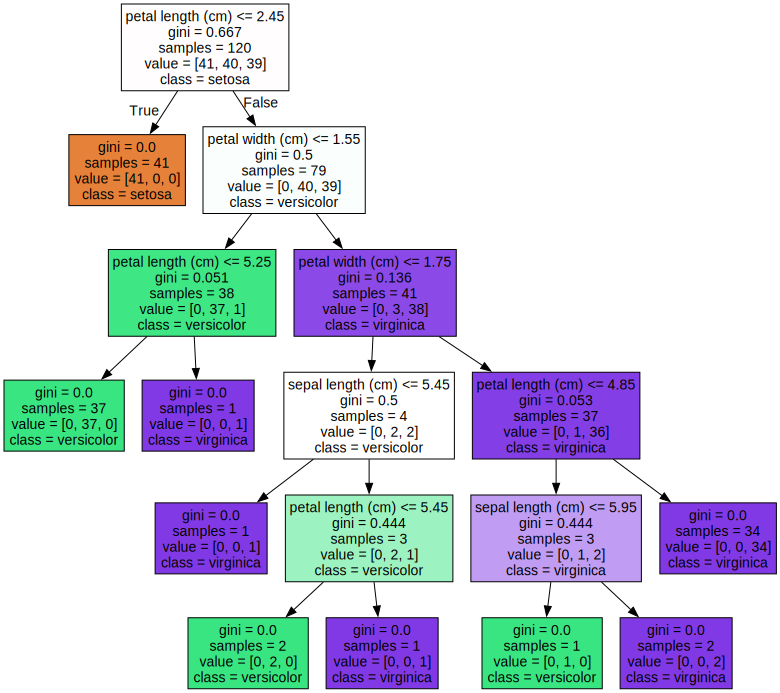

In [4]:
import graphviz
# 위에서 생성된 tree.dot 파일을 Graphviz가 읽어서 주피터 노트북상에서 시각화
with open("tree.dot") as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

각 규칙에 따라 트리의 브랜치(branch) 노드와 말단 리프(leaf) 노드가 어떻게 구성되는지 한눈에 알 수 있게 시각화되어 있다.

더 이상 자식 노드가 없는 노드는 리프 노드이다. 리프 노드는 최종 클래스(레이블) 값이 결정되는 노드이다. 리프 노드가 되려면 오직 하나의 클래스 값으로 최종 데이터가 구성되거나 리프 노드가 될 수 있는 하이퍼 파라미터 조건을 충족하면 된다. 자식 노드가 있는 노드는 브랜치 노드이며 자식 노드를 만들기 위한 분할 규칙 조건을 가지고 있다.

- petal length(cm) <= 2.45와 같이 피처의 조건이 있는 것은 자식 노드를 만들기 위한 규칙 조건이다. 이 조건이 없으면 리프 노드이다.
- gini는 다음의 value=[]로 주어진 데이터 분포에서의 지니 계수이다.
- sample는 현 규칙에 해당하는 데이터 건수이다.
- value = []는 클래스 값 기반의 데이터 건수이다. 붓꽃 데이터 세트는 클래스 값으로 0, 1, 2를 가지고 있으며, 0: Setosa 41개, 1: Versicolor, 2: Virginica, 품종을 가리킨다. 만일 Value = [41, 40, 39]라면 클래스 값의 순서로 Setosa 41개, Versicolor 40개, Virginica 39개로 데이터가 구성돼 있다는 의미이다.

- samples = 120개는 전체 데이터가 120개라는 의미
- value = [41, 40, 39]는 Setosa 41개, Versicolor 40개, Virginica 39개로 데이터 구성
- sample 120개가 value = [41, 40, 39] 분포도로 되어 있으므로 지니 계수는 0.667
- petal length (cm) <= 2.45 규칙으로 자식 노드 생성
- class = setosa는 하위 노드를 가질 경우에 setosa의 개수가 41개로 제일 많다는 의미

상단 주황색 노드는 petal length (cm) <= 2.45가 True인 규칙으로 생성되는 리프 노드이며, 다음과 같은 의미를 가진다.

- 41개의 샘플 데이터 모두 Setosa이므로 예측 클래스는 Setosa로 결정
- 지니 계수는 0임

상단 흰색 노드는 Petal  length (cm) <= 2.45가 False인 규칙 노드이다.

- 79개의 샘플 데이터 중 Versicolor 40개, Virginica 39개, 여전히 지니 계수는 0.5로 높으므로 다음 자식 브랜치 노드로 분기할 규칙 필요
- petal width (cm) <= 1.55 규칙으로 자식 노드 생성

상단 초록색 노드는 Petal width (cm) <= 1.55가 True인 규칙 노드이다.

- 38개의 샘플 데이터 중 Versicolor 37개, Virginica 1개로 대부분이 versicolor임
- 지니 계수는 0.051로 매우 낮으나 여전히 Versicolor와 Virginica가 혼재되어 있으므로 petal width(cm) <= 1.75라는 새로운 규칙으로 다시 자식 노드 생성

상단 보라색 노드는 Petal width (cm) <= 1.55가 False인 규칙 노드이다.

- 41개의 샘플 데이터 중 Versicolor 3개, Virginica 38개로 대부분이 virginica임
- 지니 계수는 0.136으로 낮으나 여전히 Versicolor와 Virginica가 혼재되어 있으므로 petal width(cm) <= 1.75라는 새로운 규칙으로 다시 자식 노드 생성

각 노드의 색깔은 붓꽃 데이터의 레이블 값을 의미한다. 주황색은 0: Setisa, 초록색은 1: Versicolor, 보라색은 2: Virginica 레이블을 나타낸다. 색깔이 짙어질수록 지니 계수가 낮고 해당 레이블에 속하는 샘플 데이터가 많다는 의미이다.

결정 트리는 과적합이 상당히 높은 ML 알고리즘이다. 이 때문에 결정 트리 알고리즘을 제어하는 대부분 하이퍼 파라미터는 복잡한 트리가 생성되는 것을 막기 위한 용도이다.

max_depth는 결정 트리의 최대 트리 깊이를 제어한다. max_depth를 제한 없음에서 3개로 설정하면 트리 깊이가 설정된 max_depth에 따라 줄어들면서 더 간단한 결정 트리가 된다.

min_samples_splits는 자식 규칙 노드를 분할해 만들기 위한 최소한의 샘플 데이터 개수이다.

min_samples_leaf는 분할될 경우 왼쪽과 오른쪽 자식 노드 각각이 가지게 될 최소 데이터 건수를 지정한다. 즉 어떤 노드가 분할할 경우, 왼쪽과 오른족 자식 노드 중에 하나라도 min_smaples_leaf로 지정된 최소 데이터 건수보다 더 작은 샘플 데이터 건수를 갖게 된다면, 해당 노드는 더 이상 분할하지 않고 리프 노드가 된다. min_samples_leaf의 값을 키우게 되면 더 이상 분할되지 않고 리프 노드가 될 수 있는 가능성이 높아진다.

사이킷런은 결정 트리 알고리즘이 학습을 통해 규칙을 정하는 데 있어 피처의 중요한 역할 지표를 DecisionTreeClassifier 객체의 feature_importances_속성으로 제공한다.

feature_importances_는 ndarray 형태로 값을 반환하며 피처 순서대로 값이 할당된다. feature_importances_는 피처가 트리 분할 시 정보 이득이나 지니 계수를 얼마나 효율적으로 잘 개선시켰는지를 정규화된 값으로 표현한 것이다. 예외 사항이 있지만, 일반적으로 값이 높을수록 해당 피처의 중요도가 높다는 의미이다. fit()으로 학습된 DecisionTreeClassifier 객체 변수인 df_clf에서 feature_importances_속성을 가져와 피처별로 중요도 값을 매핑하고 이를 막대그래프로 표현해 본다.

Feature importances:
[0.025 0.    0.555 0.42 ]
sepal length (cm): 0.025
sepal width (cm): 0.000
petal length (cm): 0.555
petal width (cm): 0.420


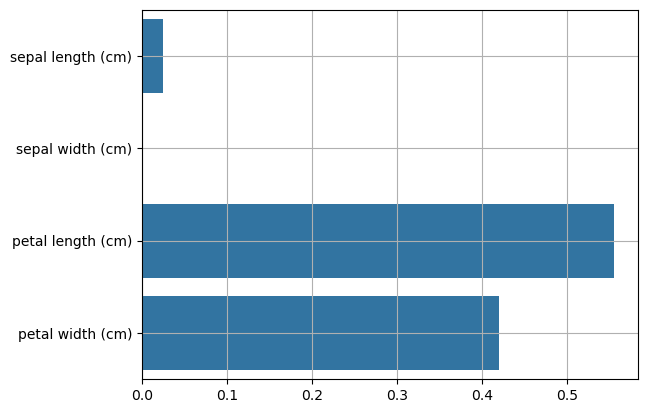

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

# feature importance 추출
print("Feature importances:\n{0}".format(np.round(dt_clf.feature_importances_, 3)))

# feature별 importance 매핑
for name, value in zip(iris_data.feature_names, dt_clf.feature_importances_):
    print('{0}: {1:.3f}'.format(name, value))
    
# feature importance를 column 별로 시각화하기
sns.barplot(x=dt_clf.feature_importances_, y=iris_data.feature_names)
plt.grid()
plt.show()

여러 피처들 중 petal_length가 가장 중요도가 높음을 알 수 있다.

#### **결정 트리 과적합(Overfitting)**

사이킷런은 분류를 위한 테스트용 데이터를 쉽게 만들 수 있도록 make_classification() 함수를 제공한다. make_classification() 호출 시 반환되는 객체는 피처 데이터 세트와 클래스 레이블 데이터 세트이다.

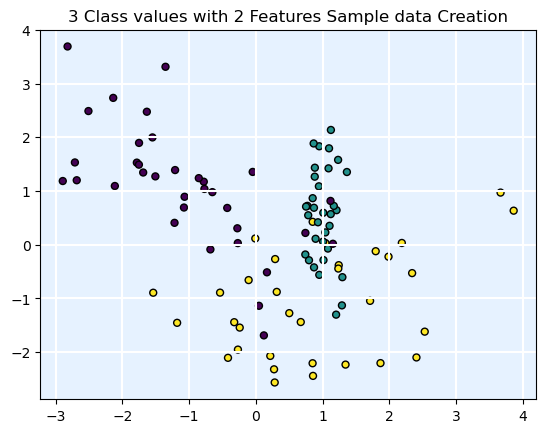

In [6]:
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
%matplotlib inline

plt.title("3 Class values with 2 Features Sample data Creation")

# 2차원 시각화를 위해서 피처는 2개, 클래스는 3가지 유형의 분류 샘플 데이터 생성
X_features, y_labels = make_classification(n_features=2, n_redundant=0, n_informative=2, n_classes=3, n_clusters_per_class=1, random_state=0)

# 그래프 형태로 2개의 피처로 2차원 좌표 시각화, 각 클래스 값은 다른 색깔로 표시됨
plt.scatter(X_features[:, 0], X_features[:, 1], marker='o', c=y_labels, s=25, edgecolor='k')
plt.gca().set_facecolor('#E6F2FF') 
plt.grid(c='white', lw=1.5)
plt.show()

각 피처가 X, Y축으로 나열된 2차원 그래프이며, 3개의 클래스 값 구분은 색깔로 되어있다. X_features와 y_labels 데이터 세트를 기반으로 결정 트리를 학습한다.

결정 트리 모델이 어떠한 결정 기준을 가지고 분할하면서 데이터를 분류하는지 확인할 것이다. 이를 위해 별도의 함수인 visualize_boundary()를 생성한다. 해당 함수는 머신러닝 모델이 클래스 값을 예측하는 결정 기준을 색상과 경계로 나타내 모델이 어떻게 데이터 세트를 에측 분류하는지 잘 이해할 수 있게 해준다.

In [7]:
def visualize_boundary(model, X, y):
    # 좌표 범위 설정
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    # 그리드 생성
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    # 예측
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # 결정 경계 시각화
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=25)
    plt.show()

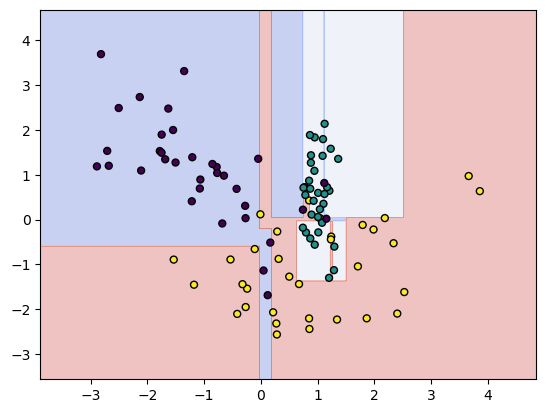

In [8]:
from sklearn.tree import DecisionTreeClassifier

# 특정한 트리 생성 제약 없는 결정 트리의 학습과 결정 경계 시각화
dt_clf = DecisionTreeClassifier(random_state=156).fit(X_features, y_labels)
visualize_boundary(dt_clf, X_features, y_labels)

일부 이상치(Outlier) 데이터까지 분류하기 위해 분할이 자주 일어나서 결정 기준 경계가 매우 많아졌다. 이렇게 복잡한 모델은 학습 데이터 세트의 특성과 약간만 다른 형태의 데이터 세트를 예측하면 예측 정확도가 떨어지게 된다.

min_samples_leaf = 6을 설정해 6개 이하의 데이터는 리프 노드를 생성할 수 있도록 리프 노드 생성 규칙을 완화한 뒤 하이퍼 파라미터를 변경해 어떻게 결정 기준 경계가 변하는지 살펴본다.

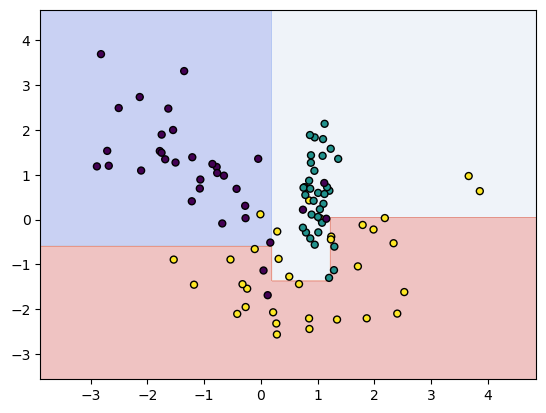

In [9]:
# min_samples_leaf=6으로 트리 생성 조건을 제약한 결정 경계 시각화
dt_clf = DecisionTreeClassifier(min_samples_leaf=6, random_state=156).fit(X_features, y_labels)
visualize_boundary(dt_clf, X_features, y_labels)

이상치에 크게 반응하지 않으면서 좀 더 일반화된 분류 규칙에 따라 분류됐음을 알 수 있다. 다양한 테스트 데이터 세트를 기반으로 한 결정 트리 모델의 예측 성능은 첫 번째 모델보다는 min_samples_leaf=6으로 트리 생성 조건을 제약한 모델이 더 뛰어날 가능성이 높다. 왜냐하면 테스트 데이터 세트는 학습 데이터 세트와는 다른 데이터 세트인데, 학습 데이터에만 지나치게 최적화된 분류 기준은 오히려 테스트 데이터 세트에서 정확도를 떨어뜨릴 수 있기 때문이다.

#### **결정 트리 실습 - 사용자 행동 인식 데이터 세트**

결정 트리를 이용해 UCI 머신러닝 리포지토리(Machine Learning Repository) 데이터 세트에 대한 예측 분류를 수행해본다. 해당 데이터는 30명에게 스마트폰 센서를 장착한 뒤 사람의 동작과 관련된 여러 가지 피처를 수집한 데이터이다.

feature.txt에는 피처의 이름이 기술돼 있다. activity_labels.txt는 동작 레이블 값에 대한 설명이 있다. human_activity의 서브 디렉터리인 train과 test 디렉터리에는 학습(Train) 용도의 피처 데이터 세트와 레이블 데이터 세트, 테스트(Test)용 피처 데이터 세트와 클래스 값 데이터 세트가 들어 있다.

피처는 모두 561개가 있으며, 공백으로 분리돼 있다. 'features.txt' 파일은 피처 인덱스와 피처명을 가지고 있으므로 이 파일을 DataFrame으로 로딩해 피처의 명칭만 간략히 확인해 본다.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# features.txt 파일에는 피처 이름 index와 피처명이 공백으로 분리되어 있음. 이를 DataFrame으로 로드
feature_name_df = pd.read_csv(r'C:\Users\user208\Desktop\자기계발\파이썬 머신러닝 완벽 가이드\DataFiles\human+activity+recognition+using+smartphones\UCI HAR Dataset\features.txt',
                              sep=r'\s+', header=None, names=['column_index', 'column_name'], engine='python')

# 피처명 index를 제거하고, 피처명만 리스트 객체로 생성한 뒤 샘플로 10개만 추출
feature_name = feature_name_df.iloc[:, 1].values.tolist()
print('전체 피처명에서 10개만 추출:', feature_name[:10])

전체 피처명에서 10개만 추출: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']


피처명을 보면 인체의 움직임과 관련된 속성의 평균/표준편차가 X, Y, Z축 값으로 돼 있음을 유추할 수 있다. 피처명을 가지고 있는 feature.txt 파일은 중복된 피처명을 가지고 있다. 이 중복된 피처명들을 이용해 파일을 데이터 세트 DataFrame에 로드하면 오류가 발생한다. 원본 피처명에 _1 또는 _2를 추가로 부여해 변경한 뒤에 이를 이용해서 데이터를 DataFrame에 로드한다.

In [11]:
feature_dup_df = feature_name_df.groupby('column_name').count()
print(feature_dup_df[feature_dup_df['column_index'] > 1].count())
feature_dup_df[feature_dup_df['column_index'] > 1].head()

column_index    42
dtype: int64


,column_index
column_name,
"fBodyAcc-bandsEnergy()-1,16",3
"fBodyAcc-bandsEnergy()-1,24",3
"fBodyAcc-bandsEnergy()-1,8",3
"fBodyAcc-bandsEnergy()-17,24",3
"fBodyAcc-bandsEnergy()-17,32",3


총 42개의 피처명이 중복돼 있다. 이 중복된 피처명에 대해서는 원본 피처명에 _1 또는 _2를 추가로 부여해 새로운 피처명을 가지는 DataFrame을 반환하는 함수인 get_new_feature_name_df()를 생성한다.

In [12]:
def get_new_feature_name_df(old_feature_name_df):
    feature_dup_df = pd.DataFrame(data=old_feature_name_df.groupby('column_name').cumcount(), columns=['dup_cnt'])
    feature_dup_df = feature_dup_df.reset_index()
    new_feature_name_df = pd.merge(old_feature_name_df.reset_index(), feature_dup_df, how='outer')
    new_feature_name_df['column_name'] = new_feature_name_df[['column_name', 'dup_cnt']].apply(lambda x : x.iloc[0] + '_' + str(x.iloc[1])
                                                                                        if x.iloc[1] > 0 else x.iloc[0], axis=1)
    new_feature_name_df = new_feature_name_df.drop(['index'], axis=1)
    return new_feature_name_df

train 디렉터리에 있는 학습용 피처 데이터 세트와 레이블 데이터 세트, test 디렉터리에 있는 테스트용 피처 데이터 파일과 레이블 데이터 파일을 각각 학습/테스트용 DataFrame에 로드한다. 각 데이터 파일은 공백으로 분리돼 있으므로 read_csv()의 sep 인자로 공백 문자를 입력한다. 레이블의 칼럼은 'action'으로 명명한다. DataFrame을 생성하는 로직을  get_new_feature_name_df() 함수로 get_human_dataset() 내에서 적용돼 중복된 피처명을 새로운 피처명으로 할당한다.

In [13]:
import pandas as pd

def get_human_dataset():

    # 각 데이터 파일은 공백으로 분리되어 있으므로 read_csv에서 공백 문자를 sep으로 할당
    feature_name_df = pd.read_csv(r'C:\Users\user208\Desktop\자기계발\파이썬 머신러닝 완벽 가이드\DataFiles\human+activity+recognition+using+smartphones\UCI HAR Dataset\features.txt', sep=r'\s+',
                                  header=None, names=['column_index', 'column_name'])

    # 중복된 피처명을 수정하는 get_new_feature_name_df()를 이용, 신규 피처명 DataFrame 생성
    new_feature_name_df = get_new_feature_name_df(feature_name_df)

    # DataFrame에 피처명을 칼럼으로 부여하기 위해 리스트 객체로 다시 변환
    feature_name = new_feature_name_df.iloc[:, 1].values.tolist()

    # 학습 피처 데이터세트와 테스트 피처 데이터를 DataFrame으로 로딩. 칼럼명은 feature_name 적용
    X_train = pd.read_csv(r'C:\Users\user208\Desktop\자기계발\파이썬 머신러닝 완벽 가이드\DataFiles\human+activity+recognition+using+smartphones\UCI HAR Dataset\train\X_train.txt', sep=r'\s+', names=feature_name)
    X_test = pd.read_csv(r'C:\Users\user208\Desktop\자기계발\파이썬 머신러닝 완벽 가이드\DataFiles\human+activity+recognition+using+smartphones\UCI HAR Dataset\test\X_test.txt', sep=r'\s+', names=feature_name)

    # 학습 레이블과 테스트 레이블 데이터를 DataFrame으로 로딩. 칼럼명은 action으로 부여
    y_train = pd.read_csv(r'C:\Users\user208\Desktop\자기계발\파이썬 머신러닝 완벽 가이드\DataFiles\human+activity+recognition+using+smartphones\UCI HAR Dataset\train\y_train.txt', sep=r'\s+', header=None, names=['action'])
    y_test = pd.read_csv(r'C:\Users\user208\Desktop\자기계발\파이썬 머신러닝 완벽 가이드\DataFiles\human+activity+recognition+using+smartphones\UCI HAR Dataset\test\y_test.txt', sep=r'\s+', header=None, names=['action'])

    # 로드된 학습/테스트용 DataFrame을 모두 반환
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = get_human_dataset()
print('## 학습 피처 데이터셋 info()')
X_train.info()

## 학습 피처 데이터셋 info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 561 entries, tBodyAcc-mean()-X to angle(Z,gravityMean)
dtypes: float64(561)
memory usage: 31.5 MB


학습 데이터 세트는 7352개의 레코드로 561개의 피처를 가지고 있다. 피처가 전부 float 형의 숫자형이므로 별도의 카테고리 인코딩은 수행할 필요가 없다.

In [14]:
print(y_train['action'].value_counts())

action
6    1407
5    1374
4    1286
1    1226
2    1073
3     986
Name: count, dtype: int64


레이블 값은 1, 2, 3, 4, 5, 6의 6개 값이고 분포도는 특정 값으로 왜곡되지 않고 비교적 고르게 분포돼 있다.

사이킷런의 DecisionTreeClassifier를 이용해 동작 예측 분류를 수행해 본다. 먼저 DecisionTreeClassifier의 하이퍼 파라미터는 모두 디폴트 값으로 설정해 수행하고, 이때의 하이퍼 파라미터 값을 모두 추출해 본다.

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 예제 반복 시마다 동일한 예측 결과 도출을 위해 random_state 설정
dt_clf = DecisionTreeClassifier(random_state=156)
dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print('결정 트리 예측 정확도: {0:.4f}'.format(accuracy))

# DecisionTreeClassifier의 하이퍼 파라미터 추출
print('DicisionTreeClassifier 기본 하이퍼 파라미터:\n', dt_clf.get_params())

결정 트리 예측 정확도: 0.8548
DicisionTreeClassifier 기본 하이퍼 파라미터:
 {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 156, 'splitter': 'best'}


약 85.48%의 정확도를 나타내고 있다.

이번에는 결정 트리의 트리 깊이(Tree Depth)가 예측 정확도에 주는 영향을 살펴본다. GridSearchCV를 이용해 사이킷런 결정 트리의 깊이를 조절할 수 있는 하이퍼 파라미터인 max_depth 값을 변화시키면서 예측 성능을 확인해 본다. min_sample_split는 16으로 고정하고 max_depth를 6, 8, 10, 12, 16, 20, 24로 계속 늘리면서 예측 성능을 측정한다. 교차 검증은 5개 세트이다.

In [16]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth' : [6, 8, 10, 12, 16, 20, 24],
    'min_samples_split' : [16]
}

grid_cv = GridSearchCV(dt_clf, param_grid=params, scoring='accuracy', cv=5, verbose=1)
grid_cv.fit(X_train, y_train)
print('GridSearchCV 최고 평균 정확도 수치: {0:.4f}'.format(grid_cv.best_score_))
print('GridSearchCV 최적 하이퍼 파라미터:', grid_cv.best_params_)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
GridSearchCV 최고 평균 정확도 수치: 0.8549
GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 8, 'min_samples_split': 16}


max_depth가 8일 때 5개의 폴드 세트의 최고 평균 정확도 결과가 약 85.49%로 도출되었다. 5개의 CV 세트에서 max_depth 값에 따라 어떻게 예측 성능이 변했는지 GridSearchCV 객체의 cv_results_ 속성을 통해 살펴본다. GridSearchCV 객체의 cv_results_ 속성은 CV세트에 하이퍼 파라미터를 순차적으로 입력했을 때의 성능 수치를 가지고 있다. max_depth에 따른 평가 데이터 세트의 평균 정확도 수치(cv_results_의 'mean_test_score'값)를 cv_results_에서 추출해 본다.

In [17]:
# GridSearchCV 객체의 cv_results_ 속성을 DataFrame으로 생성
cv_results_df = pd.DataFrame(grid_cv.cv_results_)

# max_depth 파라미터 값과 그때의 테스트 세트, 학습 데이터 세트의 정확도 수치 추출
cv_results_df[['param_max_depth', 'mean_test_score']]

,param_max_depth,mean_test_score
0,6,0.847662
1,8,0.854879
2,10,0.852705
3,12,0.845768
4,16,0.847127
5,20,0.848624
6,24,0.848624


mean_test_score는 5개 CV 세트에서 검증용 데이터 세트의 정확도 평균 수치이다.

별도의 테스트 데이터 세트에서 결정 트리의 정확도를 측정해 본다. 별도의 테스트 데이터 세트에서 min_samples_split은 16으로 고정하고 max_depth의 변화에 따른 값을 측정해 본다.

In [18]:
max_depths = [6, 8, 10, 12, 16, 20, 24]

# max_depth 값을 변화시키면서 그때마다 학습과 테스트 세트에서의 예측 성능 측정
for depth in max_depths:
    dt_clf = DecisionTreeClassifier(max_depth=depth, min_samples_split=16, random_state=156)
    dt_clf.fit(X_train, y_train)
    pred = dt_clf.predict(X_test)
    accuracy = accuracy_score(y_test, pred)
    print('max_depth = {0} 정확도: {1:.4f}'.format(depth, accuracy))

max_depth = 6 정확도: 0.8551
max_depth = 8 정확도: 0.8717
max_depth = 10 정확도: 0.8599
max_depth = 12 정확도: 0.8571
max_depth = 16 정확도: 0.8599
max_depth = 20 정확도: 0.8565
max_depth = 24 정확도: 0.8565


max_depth가 8일 경우 약 87.17%로 가장 높은 정확도를 나타냈다.

max_depth와 min_samples_split을 같이 변경하면서 정확도 성능을 튜닝해 본다.

In [19]:
params = {
    'max_depth' : [8, 12, 16, 20],
    'min_samples_split' : [16, 24]
}

grid_cv = GridSearchCV(dt_clf, param_grid=params, scoring='accuracy', cv=5, verbose=1)
grid_cv.fit(X_train, y_train)
print('GridSearchCV 최고 평균 정확도 수치: {0:.4f}'.format(grid_cv.best_score_))
print('GridSearchCV 최적 하이퍼 파라미터:', grid_cv.best_params_)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
GridSearchCV 최고 평균 정확도 수치: 0.8549
GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 8, 'min_samples_split': 16}


max_depth가 8, min_samples_split이 16일 때 가장 최고의 정확도로 약 85.49%를 나타낸다. GridSearchCV 객체인 grid_cv의 속성인 best_estimator_는 최적 하이퍼 파라미터인 max_depth 8, min_samples_split 16으로 학습이 완료된 Estimator 객체이다. 이를 이용해 테스트 데이터 세트에 예측을 수행한다.

In [20]:
best_df_clf = grid_cv.best_estimator_
pred1 = best_df_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred1)
print('결정 트리 예측 정확도: {0:.4f}'.format(accuracy))

결정 트리 예측 정확도: 0.8717


max_depth 8, min_samples_split 16일 때 테스트 데이터 세트의 예측 정확도는 약 87.17%이다. 마지막으로 결정 트리에서 각 피처의 중요도를 feature_importances_ 속성을 이용해 알아본다.

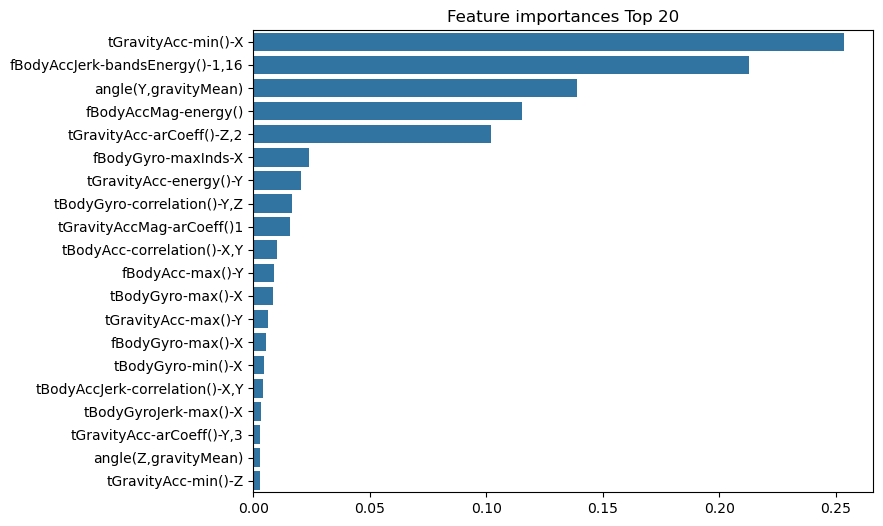

In [21]:
import seaborn as sns

ftr_importances_values = best_df_clf.feature_importances_
# Top 중요도로 정렬을 쉽게 하고, 시본(Seaborn)의 막대그래프로 쉽게 표현하기 위해 Series 변환
ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns)
# 중요도값 순으로 Series를 정렬
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]
plt.figure(figsize=(8, 6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.xlabel('')
plt.ylabel('')
plt.show()

## **03 앙상블 학습**

#### **앙상블 학습 개요**

앙상블 학습(Ensemble Learning)을 통한 분류는 여러 개의 분류기(Classifier)를 생성하고 그 예측을 결합함으로써 보다 정확한 최종 예측을 도출하는 기법이다. 앙상블 학습의 목표는 다양한 분류기의 예측 결과를 결합함으로써 단일 분류기보다 신뢰성이 높은 예측값을 얻는 것이다.

이미지, 영상, 음성 등의 비정형 데이터의 분류는 딥러닝이 뛰어난 성능을 보이고 있지만, 대부분의 정형 데이터 분류 시에는 앙상블이 뛰어난 성능을 나타내고 있다. 앙상블 알고리즘의 대표적인 랜덤 포레스트와 그래디언트 부스팅 알고리즘은 뛰어난 성능과 쉬운 사용, 다양한 활용도로 인해 그간 분석가 및 데이터 과학자들 사이에서 많이 애용됐다. 부스팅 계열의 앙상블 알고리즘의 인기와 강세가 계속 이어져 기존의 그래디언트 부스팅을 뛰어넘는 새로운 알고리즘의 개발이 가속화되었다.

데이터 과학자들이 기량을 겨루는 오픈 플랫폼인 캐글(Kaggle)에서 '매력적인 솔루션'으로 불리는 XGBoost, 그리고 XGBoost와 유사한 예측 성능을 가지면서도 훨씬 빠른 수행 속도를 가진 LightGBM, 여러 가지 모델의 결과를 기바능로 메타 모델을 수립하는 스태킹(Stacking)을 포함해 다양한 유형의 앙상블 알고리즘이 머신러닝의 선도 알고리즘으로 인기를 모으고 있다.

앙상블 학습의 유형은 전통적으로 보팅(Voting), 배깅(Bagging), 부스팅(Boosting)의 세 가지로 나눌 수 있으며, 이 외에도 스태킹(Stacking)을 포함한 다양한 앙상블 방법이 있다. 보팅과 배깅은 여러 개의 분류기가 투표를 통해 최종 예측 결과를 결정하는 방식이다. 보팅과 배깅의 다른 점은 보팅의 경우 일반적으로 서로 다른 알고리즘을 가진 분류기를 결합하는 것이고, 배깅의 경우 각각의 분류기가 모두 같은 유형의 알고리즘 기반이지만, 데이터 샘플링을 서로 다르게 가져가면서 학습을 수행해 보팅을 수행하는 것이다. 대표적인 배깅 방식이 바로 랜덤 포레스트 알고리즘이다.

개별 Clasifier에게 데이터를 샘플링해서 추출하는 방식을 부트스트래핑(Bootstrapping) 분할 방식이라고 부른다. 개별 분류기가 부트스트래핑 방식으로 샘플링된 데이터 세트에 대해서 학습을 통해 개별적인 예측을 수행한 결과를 보팅을 통해서 최종 예측 결과를 선정하는 방식이 바로 배깅 앙상블 방식이다. 교차 검증이 데이터 세트 간에 중첩을 허용하지 않는 것과 다르게 배깅 방식은 중첩을 허용한다. 따라서 10,000개의 데이터를 10개의 분류기가 배깅 방식으로 나누더라도 각 1,000개의 데이터 내에는 중복된 데이터가 있다.

부스팅은 여러 개의 분류기가 순차적으로 학습을 수행하되, 앞에서 학습한 분류기가 예측이 틀린 데이터에 대해서는 올바르게 예측할 수 있도록 다음 분류기에는 가중치(weight)를 부여하면서 학습과 예측을 진행하는 것이다. 계속해서 분류기에 가중치를 부스팅하면서 학습을 진행하기에 부스팅 방식으로 불린다. 예측 성능이 뛰어나 앙상블 학습을 주도하고 있으며 대표적인 부스팅 모듈로 그래디언트 부스트, XGBoost(eXtra Gradient Boost), LightGBM(Light Gradient Boost)이 있다.

스태킹은 여러 가지 다른 모델의 예측 결괏값을 다시 학습 데이터로 만들어서 다른 모델(메타 모델)로 재학습시켜 결과를 예측하는 방법이다.

#### **보팅 유형 - 하드 보팅(Hard Voting)과 소프트 보팅(Soft Voting)**

보팅 방법에는 두 가지가 있다. 하드 보팅과 소프트 보팅이다. 하드 보팅을 이용한 분류(Classification)는 다수결 원칙과 비슷하다. 예측한 결괏값들 중 다수의 분류기가 결정한 예측값을 최종 보팅 결과값으로 선정하는 것이다. 소프트 보팅은 분류기들의 레이블 값 결정 확률을 모두 더하고 이를 평균해서 이들 중 가장 높은 레이블 값을 최종 보팅 결괏값으로 선정한다. 하드 보팅은 다수결의 원칙이고 소프트 보팅은 각 분류기의 레이블 값 예측 확률을 평균 내어 최종 결정한다.

일반적으로 하드 보팅보다는 소프트 보팅이 예측 성능이 좋아서 더 많이 사용된다.

#### **보팅 분류기(Voting Classifier)**

사이킷런은 보팅 방식의 앙상블을 구현한 VotingClassifier 클래스를 제공한다.

보팅 방식의 앙상블을 이용해 위스콘신 유방암 데이터 세트를 예측 분석해 본다. 위스콘신 유방암 데이터 세트는 유방암의 악성종양, 양성종양 여부를 결정하는 이진 분류 데이터 세트이며 종양의 크기, 모양 등의 형태와 관련한 많은 피처를 가지고 있다. 사이킷런은 load_breast_cancer() 함수를 통해 자체에서 위스콘신 유방암 데이터 세트를 생성할 수 있다.

로지스틱 회귀와 KNN을 기반으로 보팅 분류기를 만들어 본다.

In [22]:
import pandas as pd

from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer()

data_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
data_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


로지스틱 회귀와 KNN을 기반으로 하여 소프트 보팅 방식으로 새롭게 보팅 분류기를 만들어 본다. VotingClassifier 클래스는 주요 생성 인자로 estimators와 voting 값을 입력받는다. estimators는 리스트 값으로 보팅에 사용될 여러 개의 Classifier 객체들을 튜플 형식으로 입력받으며 voting은 'hard' 시 하드 보팅, 'soft' 시 소프트 보팅 방식을 적용하라는 의미이다.(기본은 'hard'이다).

In [23]:
# 개별 모델은 로지스틱 회귀와 KNN임
lr_clf = LogisticRegression(solver='liblinear')
knn_clf = KNeighborsClassifier(n_neighbors=8)

# 개별 모델을 소프트 보팅 기반의 앙상블 모델로 구현한 분류기
vo_clf = VotingClassifier(estimators=[('LR', lr_clf), ('KNN', knn_clf)], voting='soft')

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target,
                                                    test_size=0.2, random_state=156)

# VotingClassifier 학습/예측/평가
vo_clf.fit(X_train, y_train)
pred = vo_clf.predict(X_test)
print('Voting 분류기 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

# 개별 모델의 학습/예측/평가
classifiers = [lr_clf, knn_clf]
for classifier in classifiers:
    classifier.fit(X_train, y_train)
    pred = classifier.predict(X_test)
    class_name = classifier.__class__.__name__
    print('{0} 정확도: {1:.4f}'.format(class_name, accuracy_score(y_test, pred)))

Voting 분류기 정확도: 0.9561
LogisticRegression 정확도: 0.9474
KNeighborsClassifier 정확도: 0.9386


K:\Anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 지정된 파일을 찾을 수 없습니다
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "K:\Anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "K:\Anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "K:\Anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "K:\Anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^

보팅 분류기가 정확도가 조금 높게 나타났는데, 보팅으로 여러 개의 기반 분류기를 결합한다고 해서 무조건 기반 분류기보다 예측 성능이 향상되지는 않는다. 데이터 특성과 분포 등 다양한 요건에 따라 오히려 기반 분류기 중 가장 좋은 분류기의 성능이 보팅했을 때보다 나을 수도 있다.

보팅과 스태킹 등은 서로 다른 알고리즘을 기반으로 하고 있지만, 배깅과 부스팅은 대부분 결정 트리 알고리즘을 기반으로 한다. 결정 트리 알고리즘은 쉽고 직관적인 분류 기준을 가지고 있지만 정확한 예측을 위해 학습 데이터의 예외 상황에 집착한 나머지 오히려 과적합이 발생해 실제 테스트 데이터에서 예측 성능이 떨어지는 현상이 발생하기 쉽다. 하지만 앙상블 학습에서는 이 같은 결정 트리 알고리즘의 단점을 수십~수천 개의 매우 많은 분류기를 결합해 다양한 상황을 학습하게 함으로써 극복하고 있다. 결정 트리 알고리즘의 장점은 그대로 취하고 단점은 보완하면서 편항-분산 트레이드오프의 효과를 극대화할 수 있다.

## **04 랜덤 포레스트**

#### **랜덤 포레스트의 개요 및 실습**

배깅(bagging)은 보팅과는 다르게, 같은 알고리즘으로 여러 개의 분류기를 만들어서 보팅으로 최종 결정하는 알고리즘이다. 배깅의 대표적인 알고리즘은 랜덤 포레스트이다. 랜덤 포레스트는 다재 다능한 알고리즘이다. 앙상블 알고리즘 중 비교적 빠른 수행 속도를 가지고 있으며, 다양한 영역에서 높은 예측 성능을 보이고 있다. 랜덤 포레스트의 기반 알고리즘은 결정 트리로서, 결정 트리의 쉽고 직관적인 장점을 그대로 가지고 있다(랜덤 포레스트뿐만 아니라 부스팅 기반의 다양한 앙상블 알고리즘 역시 대부분 결정 트리 알고리즘을 기반 알고리즘으로 채택하고 있다).

랜덤 포레스트는 여러 개의 결정 트리 분류기가 전체 데이터에서 배깅 방식으로 각자의 데이터를 샘플링해 개별적으로 학습을 수행한 뒤 최종적으로 모든 분류기가 보팅을 통해 예측 결정을 하게 된다.

랜덤 포레스트는 개별적인 분류기의 기반 알고리즘은 결정 트리이지만 개별 트리가 학습하는 데이터 세트는 전체 데이터에서 일부가 중첩되게 분리하는 것을 부트스트래핑(bootstrapping) 분할 방식이라 한다(배깅(Bagging)이 bootstrap aggregation의 줄임말이다). 원래 부트스트랩은 통계학에서 여러 개의 작은 데이터 세트를 임의로 만들어 개별 평균의 분포도를 측정하는 등의 목적을 위한 샘플링 방식을 지칭한다. 랜덤 포레스트의 서브세트(Subset) 데이터는 이러한 부트스트래핑으로 데이터가 임의로 만들어진다. 서브세트의 데이터 건수는 전체 데이터 건수와 동일하지만, 개별 데이터가 중첩되어 만들어진다.

데이터가 중첩된 개별 데이터 세트에 결정 트리 분류기를 각각 적용하는 것이 랜덤 포레스트이다. 사이킷런은 RandomForestClassifier 클래스를 통해 랜덤 포레스트 기반의 분류를 지원한다. 사용자 행동 인식 데이터 세트를 RandomForestClassifier를 이용해 예측해 본다. get_human_dataset()를 이용해 학습/테스트용 DataFrame을 가져온다.

In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 결정 트리에서 사용한 get_human_dataset()를 이용해 학습/테스트용 DataFrame 반환
X_train, X_test, y_train, y_test = get_human_dataset()

# 랜덤 포레스트 학습 및 별도의 테스트 세트로 예측 성능 평가
rf_clf = RandomForestClassifier(random_state=0, max_depth=8)
rf_clf.fit(X_train, y_train)
pred = rf_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print('랜덤 포레스트 정확도: {0:.4f}'.format(accuracy))

랜덤 포레스트 정확도: 0.9196


랜덤 포레스트는 사용자 행동 인식 데이터 세트에 대해 약 91.96%의 정확도를 보여준다.

#### **랜덤 포레스트 하이퍼 파라미터 및 튜닝**

트리 기반의 앙상블 알고리즘의 단점을 굳이 뽑자면 하이퍼 파라미터가 너무 많고, 그로 인해서 튜닝을 위한 시간이 많이 소모된다는 것이다. 트리 기반 자체의 하이퍼 파라미터가 원래 많은 데다 배깅, 부스팅, 학습, 정규화 등을 위한 하이퍼 파라미터까지 추가되므로 일반적으로 다른 ML 알고리즘에 비해 많을 수밖에 없다. 그나마 랜덤 포레스트가 적은 편에 속하는데, 결정 트리에서 사용되는 하이퍼 파라미터와 같은 파라미터가 대부분이기 때문이다.

- n_estimators: 랜덤 포레스트에서 결정 트리의 개수를 지정한다. 디폴트는 100개이다. 많이 설정할수록 좋은 성능을 기대할 수 있지만 계속 증가시킨다고 성능이 무조건 향상되는 것은 아니다. 또한 늘릴수록 학습 수행 시간이 오래 걸리는 것도 감안해야 한다.
- max_features는 결정 트리에 사용된 max_features 파라미터와 같습니다. 하지만 RandomForestClassifier의 기본 max_features는 'None'이 아니라 'auto', 즉 'sqrt'와 같다. 따라서 랜덤 포레스트를 분할하는 피처를 참조할 때 전체 피처가 아니라 sqrt(전체 피처 개수) 만큼 참조한다.(전체 피처가 16개라면 분할을 위해 4개 참조).
- max_depth나 min_samples_leaf, min_sample_split와 같이 결정 트리에서 과적합을 개선하기 위해 사용되는 파라미터가 랜덤 포레스트에도 똑같이 적용될 수 있다.

GridSearchCV를 이용해 랜덤 포레스트의 하이퍼 파라미터를 튜닝해 본다. 앞의 사용자 행동 세트를 그대로 이용하고, 튜닝 시간을 절약하기 위해 n_estimators는 100으로, CV를 2로만 설정해 최적 하이퍼 파라미터를 구해 본다.

RandomForestClassifier 생성자와 GridSearchCV 생성 시 n_jobs=-1 파라미터를 추가하면 모든 CPU 코어를 이용해 학습할 수 있다. 

In [25]:
from sklearn.model_selection import GridSearchCV

param = {
    'max_depth' : [8, 16, 24],
    'min_samples_leaf' : [1, 6, 12],
    'min_samples_split' : [2, 8, 16]
}

# RandomForestClassifier 객체 생성 후 GridSearchCV 수행
rf_clf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
grid_cv = GridSearchCV(rf_clf, param_grid=params, cv=2, n_jobs=-1)
grid_cv.fit(X_train, y_train)

print('최적 하이퍼 파라미터:\n', grid_cv.best_params_)
print('최고 예측 정확도: {0:.4f}'.format(grid_cv.best_score_))

최적 하이퍼 파라미터:
 {'max_depth': 20, 'min_samples_split': 16}
최고 예측 정확도: 0.9132


추출된 최적 하이퍼 파라미터로 다시 RandomForestClassifier를 학습시킨 뒤에 이번에는 별도의 테스트 데이터 세트에서 예측 성능을 측정해 본다.

In [26]:
rf_clf1 = RandomForestClassifier(n_estimators=100, min_samples_leaf=6, max_depth=16,
                                 min_samples_split=2, random_state=0)
rf_clf1.fit(X_train, y_train)
pred = rf_clf1.predict(X_test)
print('예측 정확도: {0:.4f}'.format(accuracy_score(y_test, pred)))

예측 정확도: 0.9260


RandomForestClassifier 역시 DecisionTreeClassifier와 똑같이 feature_importances_ 속성을 이용해 알고리즘이 선택한 피처의 중요도를 알 수 있다. 이 피처 중요도를 막대그래프로 시각화해 본다.

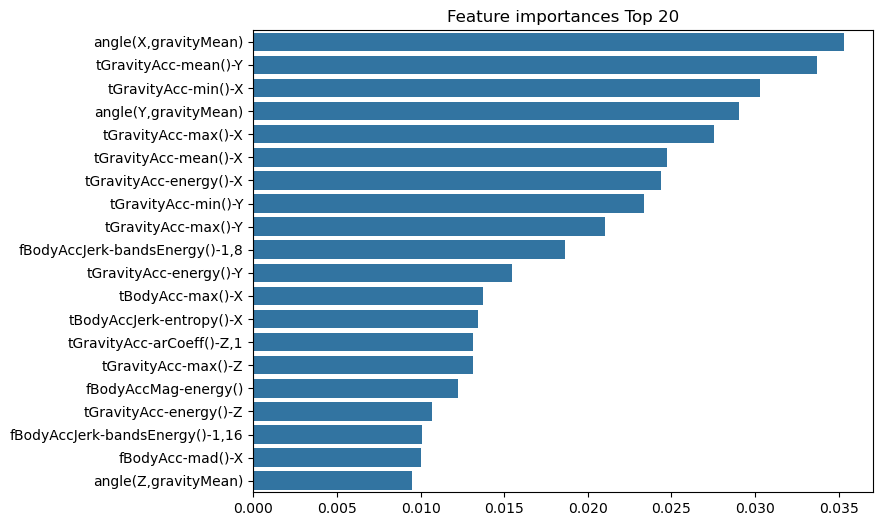

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

ftr_importances_values = rf_clf1.feature_importances_
ftr_importances = pd.Series(ftr_importances_values, index=X_train.columns)
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]

plt.figure(figsize=(8, 6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20, y=ftr_top20.index)
plt.xlabel('')
plt.ylabel('')
plt.show()

## **05 GBM(Gradient Boosting Machine)**

#### **GBM의 개요 및 실습**

부스팅 알고리즘은 여러 개의 약한 학습기(weak learner)를 순차적으로 학습-예측하면서 잘못 예측한 데이터에 가중치 부여를 통해 오류를 개선해 나가면서 학습하는 방식이다. 부스팅의 대표적인 구현은 AdaBoost(Adaptive boosting)와 그래디언트 부스트가 있다. 에이다 부스트(AdaBoost)는 오류 데이터에 가중치를 부여하면서 부스팅을 수행하는 대표적인 알고리즘이다.

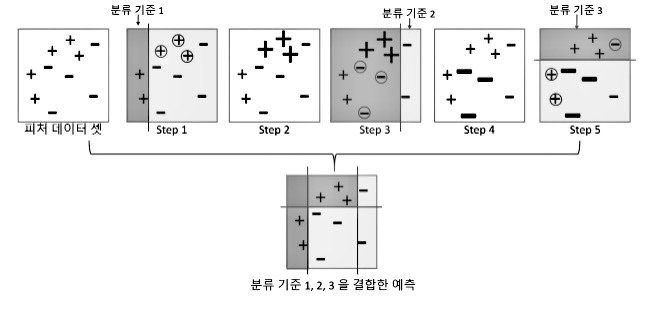

- Step 1은 첫 번째 약한 학습기(weak learner)가 분류 기준 1로 +와 -를 분류한 것이다. 동그라미로 표시된 '+' 데이터는 + 데이터가 잘못 분류된 오류 데이터이다.
- Step 2에서는 이 오류 데이터에 대해서 가중치 값을 부여한다. 가중치가 부여된 오류 + 데이터는 다음 약한 학습기가 더 잘 분류할 수 있게 크기가 커졌다.
- Step 3은 두 번째 약한 학습기가 분류 기준 2로 +와 -를 분류했다. 마찬가지로 동그라미로 표시된 '-' 데이터는 잘못 분류된 오류 데이터이다.
- Step 4에서는 잘못 분류된 이 - 오류 데이터에 대해 다음 약한 학습기가 잘 분류할 수 있게 더 큰 가중치를 부여한다.
- Step 5는 세 번째 약한 학습기가 분류 기준 3으로 +와 -를 분류하고 오류 데이터를 찾는다. 에이다부스트는 이렇게 약한 학습기가 순차적으로 오류 값에 대해 가중치를 부여한 예측 결정 기준을 모두 결합해 예측을 수행한다.
- 마지막으로 맨 아래에는 첫 번째, 두 번째, 세 번째 약한 학습기를 모두 결합한 결과 예측이다. 개별 약한 학습기보다 훨씬 정확도가 높아졌음을 알 수 있다.

GBM(Gradient Boost Machine)도 에이다부스트와 유사하나, 가중치 업데이트를 경사 하강법(Gradient Descent)을 이용하는 것이 큰 차이이다. 오류 값은 실제 값 - 예측값이다.

오류식 h(x) = y - F(x)를 최소화하는 방향성을 가지고 반복적으로 가중치 값을 업데이트하는 것이 경사 하강법(Gradient Descent)이다. 이 경사 하강법은 머신러닝에서 중요한 기법 중 하나이다.

GBM은 CART 기반의 다른 알고리즘과 마찬가지로 분류는 물론이고, 회귀도 가능하다. 사이킷런은 GBM 기반의 분류를 위해서 GradientBoostingClassifier 클래스를 제공한다. 사이킷런의 GBM을 이용해 사용자 행동 데이터 세트를 예측 분류해 본다. 또한 GBM으로 학습하는 시간이 얼마나 걸리는지 수행 시간도 같이 측정해 본다.

In [28]:
from sklearn.ensemble import GradientBoostingClassifier
import time
import warnings
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = get_human_dataset()

# GBM 수행 시간 측정을 위함. 시작 시간 설정
start_time = time.time()

gb_clf = GradientBoostingClassifier(random_state=0)
gb_clf.fit(X_train, y_train)
gb_pred = gb_clf.predict(X_test)
gb_accuracy = accuracy_score(y_test, pred)

print('GBM 정확도: {0:.4f}'.format(gb_accuracy))
print('GBM 수행 시간: {0:.1f} 초'.format(time.time() - start_time))

GBM 정확도: 0.9260
GBM 수행 시간: 520.3 초


일반적으로 GBM이 랜덤 포레스트보다는 예측 성능이 조금 뛰어난 경우가 많다. 그러나 수행 시간이 오래 걸리고, 하이퍼 파라미터 튜닝 노력도 더 필요하다. 사이킷런의 GradientBoostingClassifier는 약한 학습기의 순차적인 예측 오류 보정을 통해 학습을 수행하므로 멀티 CPU 코어 시스템을 사용하더라도 병렬처리가 지원되지 않아서 대용량 데이터의 경우 학습에 매우 많은 시간이 필요하다.

#### **GBM 하이퍼 파라미터 소개**

- **loss:** 경사 하강법에서 사용할 비용 함수를 지정한다. 특별한 이유가 없으면 기본값인 'deviance'를 그대로 적용한다.
- **learning_rate:** GBM이 학습을 진행할 때마다 적용하는 학습률이다. Weak learner가 순차적으로 오류 값을 보정해 나가는 데 적용하는 계수이다. 0~1 사이의 값을 지정할 수 있으며 기본값은 0.1이다. 너무 작은 값을 적용하면 업데이트되는 값이 작아져서 최소 오류 값을 찾아 예측 성능이 높아질 가능성이 높다. 하지만 많은 weak learner는 순차적인 반복이 필요해서 수행 시간이 오래 걸리고, 또 너무 작게 설정하면 모든 weak learner의 반복이 완료돼도 최소 오류 값을 찾지 못할 수 있다. 반대로 큰 값을 적용하면 최소 오류 값을 찾지 못하고 그냥 지나쳐 버려 예측 성능이 떨어질 가능성이 높아지지만, 빠른 수행이 가능하다. 이러한 특성 때문에 learning_rate는 n_estimators와 상호 보완적으로 조합해 사용한다. learning_rate를 작게 하고 n_estimators를 크게 하면 더 이상 성능이 좋아지지 않는 한계점까지는 예측 성능이 조금씩 좋아질 수 있다. 하지만 수행 시간이 너무 오래 걸리는 단점이 있으며, 예측 성능 역시 현격히 좋아지지는 않는다.
- **n_estimators:** weak learner의 개수이다. weak learner가 순차적으로 오류를 보정하므로 개수가 많은수록 예측 성능이 일정 수준까지는 좋아질 수 있다. 하지만 개수가 많을수록 수행 시간이 오래 걸린다. 기본값은 100이다.
- **subsample:** weak learner가 학습에 사용하는 데이터 샘플링 비율이다. 기본값은 1이며, 이는 전체 학습 데이터를 기반으로 학습한다는 의미이다(0.5이면 학습 데이터의 50%). 과적합이 염려되는 경우 subsample을 1보다 작은 값으로 설정한다.

GBM은 과적합에도 강한 뛰어난 예측 성능을 가진 알고리즘이다. 하지만 수행 시간이 오래 걸린다는 단점이 있다.

## **06 XGBoost(eXtra Gradient Boost)**

#### **XGBoost 개요**

XGBoost는 트리 기반의 앙상블 학습에서 가장 각광받고 있는 알고리즘 중 하나이다. 압도적인 수치의 차이는 아니지만, 분류에 있어서 일반적으로 다른 머신러닝보다 뛰어난 예측 성능을 나타낸다. XGBoost는 GBM에 기반하고 있지만, GBM의 단점인 느린 수행 시간 및 과적합 규제(Regularization) 부재 등의 문제를 해결해서 매우 각광을 받고 있다. 특히 XGBoost는 병렬 CPU 환경에서 병렬 학습이 가능해 기존 GBM보다 빠르게 학습을 완료할 수 있다.

|**항목**|**설명**|
|------|------|
|**뛰어난 예측 성능**| 일반적으로 분류와 회귀 영역에서 뛰어난 예측 성능을 발휘한다. |
|**GBM 대비 빠른 수행 시간**| 일반적인 GBM은 순차적으로 Weak learner가 가중치를 증가하는 방법으로 학습하기 때문에 전체적으로 속도가 느리다. 하지만 XGBoost는 병렬 수행 및 다양한 기능으로 GBM에 비해 빠른 수행 속도를 보장한다. 아래에서도 XGBoost가 일반적인 GBM에 비해 수행 시간이 빠르다는 것이지, 다른 머신러닝 알고리즘(예를 들어 랜덤 포레스트)에 비해서 빠르다는 의미는 아니다. |
|**과적합 규제 (Regularization)**| 표준 GBM의 경우 과적합 규제 기능이 없으나, XGBoost는 자체에 과적합 규제 기능으로 과적합을 좀 더 강하게 나누도록 할 수 있다. |
|**Tree pruning (나무 가지치기)**| 일반적으로 GBM은 분할 시 부정 신호가 발생하면 분할을 더 이상 수행하지 않는다. 이러한 방식도 가지치기지만 많은 분할을 발생할 수 있습니다. <br> 반면 XGBoost는 `max_depth` 파라미터로 분할 깊이를 조정하기도 하지만, `tree pruning`으로 더 이상 긍정 신호가 없는 분할을 가지치기 해서 분할을 더 줄이는 추가적인 장점을 가지고 있다. |
|**자체 내장된 교차 검증**| XGBoost는 병렬 수행 시마다 내부적으로 학습 데이터 세트와 평가 데이터 세트에 대한 교차 검증을 수행해 최적 반복 횟수를 찾을 수 있다. <br> 지정된 반복 횟수가 아니라 교차 검증을 통해 평가 데이터 세트의 평가 값이 최적화될 때 반복을 중간에 멈출 수 있는 조기 중단 기능이 있다. |
|**결손값 자체 처리**| XGBoost는 결손값을 자체 처리할 수 있는 기능을 가지고 있다. |

XGBoost의 핵심 라이브러리는 C/C++로 작성돼 있다. XGBoost 개발 그룹은 파이썬에서도 XGBoost를 구동할 수 있도록 파이썬 패키지를 제공한다. XGBoost의 파이썬 패키지명은 "xgboost"이다. xgboost 패키지 내에는 XGBoost 전용의 파이썬 패키지와 사이킷런과 호환되는 래퍼용 XGBoost가 함께 존재한다.

XGBoost 패키지의 사이킷런 래퍼 클래스는 XGBClassifier와 XGBRegressor이다. 이를 이용하면 사이킷런 estimator가 학습을 위해 사용하는 fit()과 predict()와 같은 표준 사이킷런 개발 프로세스 및 다양한 유틸리티를 활용할 수 있다.

구분을 위해서 초기의 독자적인 XGBoost 프레임워크 기반의 XGBoost를 파이썬 래퍼 XGBoost 모듈, 사이킷런과 연동되는 모듈을 사이킷런 래퍼 XGBoost 모듈이라고 지칭한다.

In [29]:
import xgboost as xgb
from xgboost import XGBClassifier

#### **파이썬 래퍼 XGBoost 하이퍼 파라미터**

XGBoost는 GBM과 유사한 하이퍼 파라미터를 동일하게 가지고 있으며, 여기에 조기 중단(early stopping), 과적합을 규제하기 위한 하이퍼 파라미터 등이 추가되었다.

파이썬 래퍼 XGBoost 모듈과 사이킷런 래퍼 XGBoost 모듈의 일부 하이퍼 파라미터는 약간 다르므로 이에 대한 주의가 필요하다.

- **일반 파라미터:** 일반적으로 실행 시 스레드의 개수나 silent 모드 등의 선택을 위한 파라미터로서 대부분 파라미터를 직접 바꾸는 경우는 거의 없습니다.
- **부스터 파라미터:** 트리 최적화, 부스팅, regularization 등과 관련 파라미터를 설정합니다.
- **학습 태스크 파라미터:** 학습 수행 시의 객체 함수, 평가를 위한 지표 등을 설정하는 파라미터입니다.

  
대부분의 하이퍼 파라미터는 Booster 파라미터에 속한다.

##### **주요 부스터 파라미터**
- **booster:** gbtree(tree based model) 또는 gblinear(linear model) 선택, 디폴트는 gbtree입니다.
- **silent:** 디폴트는 0이며, 출력 메시지를 나타내고 싶지 않을 경우 1로 설정합니다.
- **nthread:** CPU의 실행 스레드 개수를 조정하며, 디폴트는 CPU 전체 스레드를 다 사용하는 것입니다. 멀티 코어/스레드 CPU 시스템에서 전체 CPU를 사용하지 않고 일부만 CPU만 사용해 ML 애플리케이션을 구동하는 경우에 변경한다.

##### **주요 부스터 파라미터**
- **eta [default=0.3, alias: learning_rate]:** GBM의 학습률(learning rate)과 같은 파라미터입니다. 0에서 1 사이의 값을 지정하며 부스팅 스텝을 반복적으로 수행할 때 업데이트되는 학습률 값 파이썬 래퍼 기반의 xgboost를 이용할 경우 디폴트는 0.3, 사이킷런 래퍼 클래스를 이용할 경우 eta는 learning_rate 파라미터로 대체됩니다. 보통 0.01~0.2 사이의 값을 선호합니다.
- **num_boost_rounds:** GBM의 n_estimators와 같은 파라미터입니다.
- **min_child_weight [default=1]:** 트리에서 추가적으로 가지를 나눌지를 결정하기 위해 필요한 데이터들의 weight 총합. min_child_weight이 클수록 분할을 자제하고, 과적합을 조정하기 위해 사용됩니다.
- **gamma [default=0, alias: min_split_loss]:** 트리의 리프 노드를 추가적으로 분할하기 위한 최소 손실 감소 값입니다. 만약 gamma 값보다 큰 손실(loss)이 감소될 경우에 리프 노드를 분할합니다. 값이 클수록 과적합 감소 효과가 있습니다.
- **max_depth [default=6]:** 트리 기반 알고리즘의 max_depth와 같습니다. 0을 지정하면 깊이에 제한이 없습니다. Max_depth가 높으면 특정 조건에 특화되어진 조건이 만들어지므로 과적합 가능성이 높아지며 보통 3~10 사이의 값을 적용합니다.
- **sub_sample [default=1]:** GBM의 subsample과 동일합니다. 트리가 커져서 과적합되는 것을 제어하기 위해 데이터를 샘플링하는 비율을 지정합니다. sub_sample=0.5로 지정하면 전체 데이터의 절반으로 트리를 생성하는 데 사용합니다. 0에서 1 사이의 값이 가능하며 일반적으로 0.5~1 사이의 값을 사용합니다.
- **colsample_bytree [default=1]:** GBM의 max_features와 유사합니다. 트리 생성에 필요한 피처(컬럼)를 임의로 샘플링하는 데 사용됩니다. 매우 많은 피처가 있는 경우 과적합을 조정하는 데 적용합니다.
- **lambda [default=1, alias: reg_lambda]:** L2 Regularization 적용 강도입니다. 피처 개수가 많을 경우 적용을 권장하며 깊이 클수록 과적합 감소 효과가 있습니다.
- **alpha [default=0, alias: reg_alpha]:** L1 Regularization 적용 강도입니다. 피처 개수가 많을 경우 적용을 권장하며 깊이 클수록 과적합 감소 효과가 있습니다.
- **scale_pos_weight [default=1]:** 특정 값으로 치우친 비대칭한 클래스로 구성된 데이터 세트의 균형을 유지하기 위한 파라미터입니다.

##### **학습 태스크 파라미터**
- **objective:** 최소값을 가져야 할 손실 함수를 정의합니다. XGBoost는 많은 유형의 손실함수를 사용할 수 있습니다. 주로 사용하는 손실함수는 이진 분류와 다중 분류에 따라 달라집니다.
- **binary:logistic:** 이진 분류일 때 적용합니다.
- **multi:softmax:** 다중 분류일 때 적용합니다. 손실함수가 multi:softmax일 경우에는 레이블 클래스의 개수인 num_class 파라미터를 지정해야 합니다.
- **multi:softprob:** multi:softmax와 유사하나 개별 레이블 클래스의 해당되는 예측 확률을 반환합니다.
- **eval_metric:** 검증에 사용되는 함수를 정의합니다. 기본값은 회귀일 경우는 rmse, 분류일 경우에는 error입니다. 다음은 eval_metric의 값 유형입니다.
    - **rmse:** Root Mean Square Error
    - **mae:** Mean Absolute Error
    - **logloss:** Negative log-likelihood
    - **error:** Binary classification error rate (0.5 threshold)
    - **merror:** Multiclass classification error rate
    - **mlogloss:** Multiclass logloss
    - **auc:** Area under the curve

뛰어난 알고리즘일수록 파라미터를 튜닝할 필요가 적다. 그리고 파라미터 튜닝에 들이는 공수 대비 성능 향상 효과가 높지 않은 경우가 대부분이다.

과적합 문제가 심각하다면 다음과 같이 적용할 것을 고려할 수 있다.
- eta 값을 낮춘다(0.01~0.1). eta 값을 낮출 경우 num_round(또는 n_estimators)는 반대로 높여줘야 한다.
- max_depth 값을 낮춘다.
- min_child_weight 값을 높인다.
- gamma 값을 높인다.
- 또한 sub_sample과 colsample_bytree를 조정하는 것도 트리가 너무 복잡하게 생성되는 것을 막아 과적합 문제에 도움이 될 수 있다.

XGBoost 자체적으로 교차 검증, 성능 평가, 피처 중요도 등의 시각화 기능을 가지고 있다. 또한 XGBoost는 기본 GBM에서 부족한 다른 여러 가지 성능 향상 기능이 있다. 그중에 수행 속도를 향상시키기 위한 대표적인 기능으로 조기 중단(Early Stopping) 기능이 있다. XGBoost, 그리고 뒤에 소개할 LightGBM은 모두 조기 중단 기능이 있어서 n_estimators에 지정한 부스팅 반복 횟수에 도달하지 않더라도 예측 오류가 더 이상 개선되지 않으면 반복을 끝까지 수행하지 않고 중지해 수행 시간을 개선할 수 있다.

예를 들어 n_estimators를 200으로 설정하고 조기 중단 파라미터 값을 50으로 설정하면, 1부터 200회까지 부스팅을 반복하다가 50회를 반복하는 동안 학습 오류가 감소하지 않으면 더 이상 부스팅을 진행하지 않고 종료한다(가령 100회에서 학습 오류 값이 0.8인데, 101 ~ 150회 반복하는 동안 예측 오류가 0.8보다 작은 값이 하나도 없으면 부스팅을 종료한다).

In [30]:
import xgboost

print(xgboost.__version__)

3.0.1


#### **파이썬 래퍼 XGBoost 적용 - 위스콘신 유방암 예측**

위스콘신 유방암 데이터 세트를 활용하여 파이썬 래퍼 XGBoost API의 사용법을 살펴본다. 위스콘신 유방암 데이터 세트는 종양의 크기, 모양 등의 다양한 속성값을 기반으로 악성 종양(malignant)인지 양성 종양(benign)인지를 분류한 데이터 세트이다. 위스콘신 유방암 데이터 세트에 기반해 종양의 다양한 피처에 따라 악성종양(malignant)인지 일반 양성종양(beningn)인지를 XGBoost를 이용해 예측해 본다.

xgboost 모듈을 로딩하고 xgb로 명명한다. xgboost 패키지는 피처의 중요도를 시각화해주는 모듈인 plot_importances를 함께 제공한다.

In [31]:
import xgboost as xgb
from xgboost import plot_importance
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

dataset = load_breast_cancer()
features = dataset.data
labels = dataset.target
cancer_df = pd.DataFrame(data=features, columns=dataset.feature_names)
cancer_df['target'] = labels
cancer_df.head(3)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0


종양의 크기와 모양에 관련된 많은 속성이 숫자형 값으로 돼 있다. 타깃 레이블 값의 종류는 악성인 'malignant'가 0 값으로, 양성인 'benign'이 1 값으로 돼 있다.

In [32]:
print(dataset.target_names)
print(cancer_df['target'].value_counts())

['malignant' 'benign']
target
1    357
0    212
Name: count, dtype: int64


1 값인 양성 beningn이 357개, 0 값인 악성 malignant가 212개로 구성돼 있다.

위스콘신 유방암 데이터 세트의 80%를 학습용으로, 20%를 테스트용으로 추출한 뒤 이 80%의 학습용 데이터에서 90%를 최종 학습용, 10%를 검증용으로 분할한다. 여기서 검증용 데이터 세트를 별도로 분할하는 이유는 XGBoost가 제공하는 기능인 검증 성능 평가와 조기 중단(early stopping)을 수행해 보기 위함이다.

In [33]:
# cancer_df에서 feature용 DataFrame과 Label용 Series 객체 추출
# 맨 마지막 칼럼이 Label임. Feature용 DataFrame의 첫번째 칼럼에서 맨 마지막 두번재 칼럼까지를 :-1 슬라이싱으로 추출
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(X_features, y_label, test_size=0.2,
                                                    random_state=156)

# 위에서 만든 X_train, y_train을 다시 쪼개서 90%는 학습과 10%는 검증용 데이터로 분리
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=156)

print(X_train.shape, X_test.shape)
print(X_tr.shape, X_val.shape)

(455, 30) (114, 30)
(364, 30) (91, 30)


전체 509개의 데이터 세트에서 최종 학습용 409개, 검증용 4개, 테스트용 114개가 추출되었다.

파이썬 래퍼 XGBoost는 사이킷런과 여러 가지 차이가 있지만, 먼저 눈에 띄는 차이는 XGBoost만의 전용 데이터 객체인 DMatrix를 사용한다는 점이다. 때문에 Numpy 또는 Pandas로 되어 있는 학습용, 검증, 테스트용 데이터 세트를 모두 전용의 데이터 객체인 DMatrix로 생성하여 모델에 입력해 줘야 한다. DMatrix의 주요 입력 파라미터는 data와 label이다. data는 피처 데이터 세트이며, label은 분류의 경우에는 레이블 데이터 세트, 회귀의 경우는 숫자형인 종속값 데이터 세트이다.

DMatrix는 넘파이, DataFrame, Series외에 libsvm txt 포맷 파일, xgboost 이전 버퍼 파일을 파라미터로 입력받아 변환할 수 있다.

In [34]:
# 만약 구버전 XGBoost에서 DataFrame으로 DMatrix 생성이 안 될 경우 X_train.values로 넘파이 변환
# 학습, 검증, 테스트용 DMatirx를 생성
dtr = xgb.DMatrix(data=X_tr, label=y_tr)
dval = xgb.DMatrix(data=X_val, label=y_val)
dtest = xgb.DMatrix(data=X_test, label=y_test)

파이썬 래퍼 XGBoost 모듈인 xgboost를 이용해 학습을 수행하기 전에 먼저 XGBoost의 하이퍼 파라미터를 설정한다. XGBoost의 하이퍼 파라미터는 주로 딕셔너리 형태로 입력한다.

- max_depth(트리 최대 깊이)는 3
- 학습률 eta는 0.1(XGBClassifier를 사용할 경우 eta가 아니라 learning_rate이다).
- 예제 데이터가 0 또는 1 이진 분류이므로 목적함수(objective)는 이진 로지스틱(binary:logistic).
- 오류 함수의 평가 성능 지표는 logloss
- num_rounds(부스팅 반복 횟수)는 400회

In [35]:
params = {'max_depth':3,
          'eta':0.05,
          'objective':'binary:logistic',
          'eval_metric':'logloss'
         }
num_rounds = 400

파이썬 래퍼 XGBoost는 하이퍼 파라미터를 xgboost 모듈의 train() 함수에 파라미터로 전달한다(사이킷런의 경우는 Estimator의 생성자를 하이퍼 파라미터로 전달하는 데 반해 차이가 있다). 학습 시 XGBoost는 수행 속도를 개선하기 위해서 조기 중단 기능을 제공한다.

조기 중단의 성능 평가는 주로 별도의 검증 데이터 세트를 이용한다. XGBoost는 학습 반복 시마다 검증 데이터 세트를 이용해 성능을 평가할 수 있는 기능을 제공한다. 조기 중단은 xgboost의 train() 함수에 early_stopping_rounds 파라미터를 입력하여 설정한다.

early_stopping_rounds 파라미터를 설정해 조기 중단을 수행하기 위해서는 반드시 평가용 데이터 세트 지정과 eval_metric을 함께 설정해야 한다. Xgboost는 반복마다 지정된 평가용 데이터 세트에서 eval_metric의 지정된 평가 지표로 예측 오류를 측정한다.

- 평가용 데이터 세트는 학습과 평가용 데이터 세트를 명기하는 개별 튜플을 가지는 리스트 형태로 설정
- eval_metric은 평가 세트에 적용할 성능 평가 방법, 분류일 경우 주로 'error'(분류 오류), 'logloss'를 적용

평가용 데이터 세트 설정은 [(dtr,'train'), (dval,'eval')]와 같이 학습용 DMatrix인 dtr과 검증용 DMatrix인 dval로 설정한 train() 함수의 evals 인자값으로 입력한다. eval_metric는 위에서 params 딕셔너리로 지정되었다. Xgboost 학습 반복 시마다 evals에 설정된 데이터 세트에 대해 평가 지표 결과가 출력된다. train()은 학습이 완료된 모델 객체를 반환한다.

In [36]:
# 학습 데이터 셋은 'train' 또는 평가 데이터 셋은 'eval'로 명기한다.
eval_list = [(dtr,'train'), (dval, 'eval')] # 또는 eval_list = [(dval,'eval')]만 명기해도 무방

# 하이퍼 파라미터와 early stopping 파라미터를 train() 함수의 파라미터로 전달|
xgb_model = xgb.train(params = params, dtrain=dtr, num_boost_round=num_rounds,
                      early_stopping_rounds=50, evals=eval_list)

[0]	train-logloss:0.61672	eval-logloss:0.65964
[1]	train-logloss:0.57821	eval-logloss:0.62664
[2]	train-logloss:0.54351	eval-logloss:0.59774
[3]	train-logloss:0.51179	eval-logloss:0.57087
[4]	train-logloss:0.48280	eval-logloss:0.54645
[5]	train-logloss:0.45620	eval-logloss:0.52418
[6]	train-logloss:0.43095	eval-logloss:0.50264
[7]	train-logloss:0.40844	eval-logloss:0.48508
[8]	train-logloss:0.38661	eval-logloss:0.46750
[9]	train-logloss:0.36637	eval-logloss:0.45121
[10]	train-logloss:0.34757	eval-logloss:0.43552
[11]	train-logloss:0.33007	eval-logloss:0.42173
[12]	train-logloss:0.31395	eval-logloss:0.40961
[13]	train-logloss:0.29865	eval-logloss:0.39777
[14]	train-logloss:0.28435	eval-logloss:0.38619
[15]	train-logloss:0.27093	eval-logloss:0.37574
[16]	train-logloss:0.25832	eval-logloss:0.36642
[17]	train-logloss:0.24649	eval-logloss:0.35750
[18]	train-logloss:0.23553	eval-logloss:0.34804
[19]	train-logloss:0.22503	eval-logloss:0.33881
[20]	train-logloss:0.21507	eval-logloss:0.33185
[2

train()으로 학습을 수행하면서 반복 시마다 train-logloss와 eval-logloss가 지속적으로 감소하고 있다. early_stopping_rounds로 지정된 50회 동안 logloss 값은 이보다 향상되지 않았기 때문에(logloss가 작을수록 성능이 좋다) 더 반복하지 않고 멈춘 것이다.

파이썬 래퍼 XGBoost는 train() 함수를 호출해 학습이 완료된 모델 객체를 반환하게 되는데, 이 모델 객체는 예측을 위해 predict() 메서드를 이용한다. 한 가지 유의할 점은 사이킷런의 predict() 메서드는 예측 결과 클래스 값(즉, 0, 1)을 반환하는 데 반해 xgboost의 predict()는 예측 결괏값이 아닌 예측 결과를 추정할 수 있는 확률 값을 반환한다. 본 예제는 암이 악성인지, 양성인지를 판단하는 이진 분류이므로 예측 확률이 0.5보다 크면 1, 그렇지 않으면 0으로 예측 값을 결정하는 로직을 추가하면 된다.

In [37]:
pred_probs = xgb_model.predict(dtest)
print('predict() 수행 결괏값을 10개만 표시, 예측 확률 값으로 표시됨')
print(np.round(pred_probs[:10], 3))

# 예측 확률이 0.5보다 크면 1, 그렇지 않으면 예측값 결정하여 List 객체인 preds에 저장
preds = [ 1 if x > 0.5 else 0 for x in pred_probs ]
print('예측값 10개만 표시:', preds[:10])

predict() 수행 결괏값을 10개만 표시, 예측 확률 값으로 표시됨
[0.981 0.016 0.76  0.11  0.984 0.997 0.996 0.996 0.995 0.005]
예측값 10개만 표시: [1, 0, 1, 0, 1, 1, 1, 1, 1, 0]


get_clf_eval() 함수를 적용해 XGBoost 모델의 예측 성능을 평가해 본다.

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f}, F1: {3:.4f}, AUC: {4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

In [39]:
get_clf_eval(y_test, preds, pred_probs)

오차 행렬
[[34  3]
 [ 3 74]]
정확도: 0.9474, 정밀도: 0.9610, 재현율: 0.9610, F1: 0.9610, AUC: 0.9933


xgboost의 plot_importance() API는 피처의 중요도를 막대그래프 형식으로 나타낸다. 기본 평가 지표로 f스코어를 기반으로 해당 피처의 중요도를 나타낸다. f스코어는 해당 피처가 트리 분할 시 얼마나 자주 사용되었는지를 지표로 나타낸 값이다. xgboost 패키지는 plot_importance()를 이용해 바로 피처 중요도를 시각화할 수 있다. plot_importance() 호출 시 파라미터로 앞에서 학습이 완료된 모델 객체 및 맷플롯립의 ax 객체를 입력하기만 하면 된다.

내장된 plot_importance() 이용 시 유의할 점은 xgboost를 DataFrame이 아닌 넘파이 기반의 피처 데이터로 학습 시에는 넘파이에서 피처명을 제대로 알 수가 없으므로 Y축의 피처명을 나열 시 f0, f1과 같이 피처 순서별로 f자 뒤에 순서를 붙여서 피처명을 나타낸다(f0는 첫 번째 피처, f1은 두 번째 피처를 의미한다).

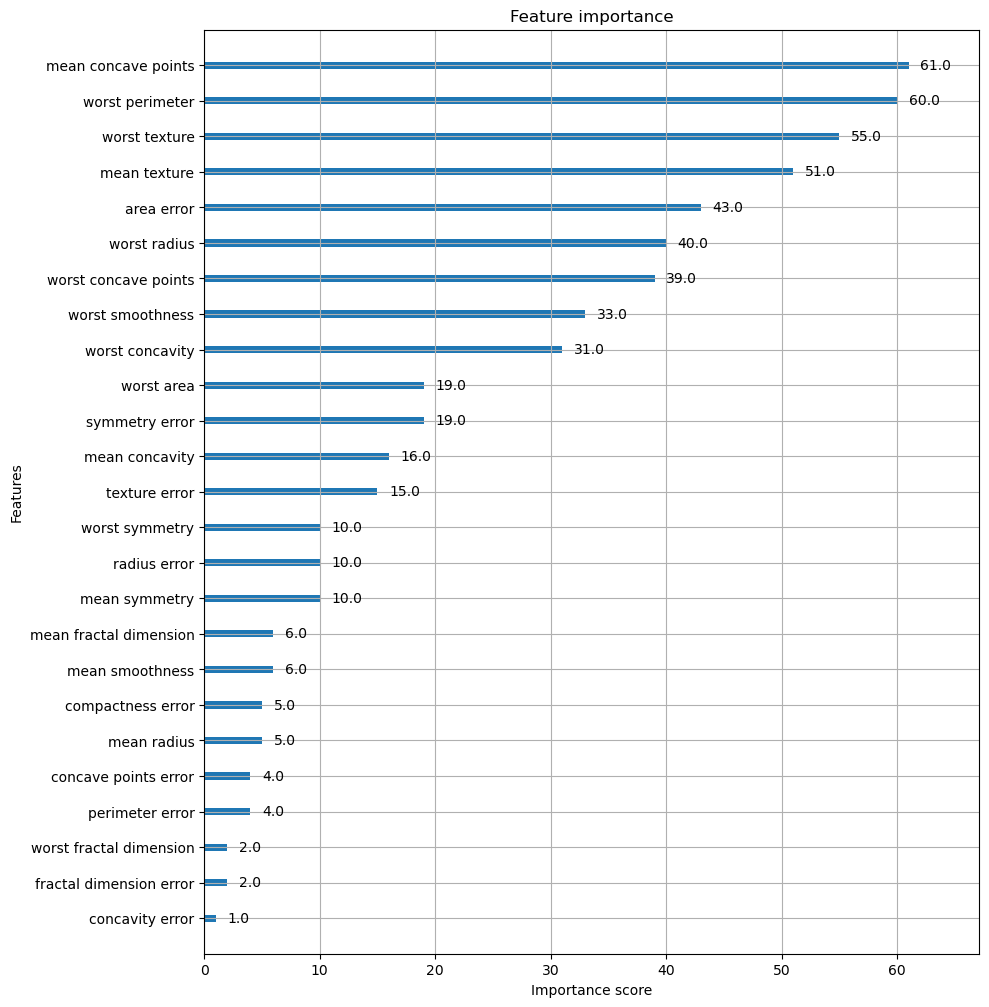

In [40]:
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(xgb_model, ax=ax)
plt.show()

결정 트리에서 보여준 트리 기반 규칙 구조도 xgboost에서 시각화할 수 있다. xgboost 모듈의 to_graphviz() API를 이용하면 주피터 노트북에 바로 규칙 트리 구조를 그릴 수 있다. 

파이썬 래퍼 XGBoost는 사이킷런의 GridSearchCV와 유사하게 데이터 세트에 대한 교차 검증 수행 후 최적 파라미터를 구할 수 있는 방법을 cv() API로 제공한다.

xgboost.cv(
    params, dtrain, num_boost_round=10, nfold=3, stratified=False,
    folds=None, metrics=(), obj=None, feval=None, maximize=False,
    early_stopping_rounds=None, fpreproc=None, as_pandas=True,
    verbose_eval=None, show_stdv=True, seed=0, callbacks=None, shuffle=True
)  

- params (dict): 부스터 파라미터
- dtrain (DMatrix): 학습 데이터
- num_boost_round (int): 부스팅 반복 횟수
- nfold (int): CV 폴드 개수
- stratified (bool): CV 수행 시 층화 표본 추출(stratified sampling) 수행 여부
- metrics (string or list of strings): CV 수행 시 모니터링할 성능 평가 지표
- early_stopping_rounds (int): 조기 중단을 활성화시킴, 반복 횟수 지정

xgb.cv의 반환값은 DataFrame 형태이다.

#### **사이킷런 래퍼 XGBoost의 개요 및 적용**

사이킷런의 기본 Esimator를 그대로 상속해 만들었기 때문에 다른 Estimator와 동일하게 fit()과 predict()만으로 학습과 예측이 가능하고, GridSearchCV, Pipeline 등 사이킷런의 다른 유틸리티를 그대로 사용할 수 있기 때문에 기존의 다른 머신러닝 알고리즘으로 만들어놓은 프로그램이 있더라도 알고리즘 클래스만 XGBoost 래퍼 클래스로 바꾸면 기존 프로그램을 그대로 사용할 수 있다. 사이킷런을 위한 래퍼 XGBoost는 크게 분류를 위한 래퍼 클래스인 XGBClassifier, 회귀를 위한 래퍼 클래스인 XGBRegressor이다.

XGBClassifier는 기존 사이킷런에서 일반적으로 사용하는 하이퍼 파라미터와 호환성을 유지하기 위해 기존의 xgboost 모듈에서 사용하던 네이티브 하이퍼 파라미터 몇 개를 다음과 같이 변경했다.  

- eta -> learning_rate
- sub_sample -> subsample
- lambda -> reg_lambda
- alpha -> reg_alpha

xgboost의 n_estimators와 num_boost_round 하이퍼 파라미터는 서로 동일한 파라미터이다. 만일 두 개가 동시에 사용되면 파이썬 래퍼 XGBoost API에서는 n_estimators 파라미터를 무시하고 num_boost_round 파라미터를 적용한다. XGBClassifier와 같은 사이킷런 래퍼 XGBoost 클래스에서는 n_estimators 파라미터를 적용한다.

위스콘신 대학병원의 유방암 데이터 세트를 분류를 위한 래퍼 클래스인 XGBClassifier를 이용해 예측해 본다. XGBClassifier 클래스의 fit(), predict(), predict_proba()를 이용해 학습과 예측을 수행한다.

In [68]:
# 사이킷런 래퍼 XGBoost 클래스인 XGBClassifier 임포트
from xgboost import XGBClassifier

# Warning 메시지를 없애기 위해 eval_metric 값을 XGBClassifier 생성 인자로 입력
xgb_wrapper = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=3, eval_metric='logloss')
xgb_wrapper.fit(X_train, y_train, verbose=True)
w_preds = xgb_wrapper.predict(X_test)
w_pred_proba = xgb_wrapper.predict_proba(X_test)[:, 1]

In [69]:
get_clf_eval(y_test, w_preds, w_pred_proba)

오차 행렬
[[34  3]
 [ 1 76]]
정확도: 0.9649, 정밀도: 0.9620, 재현율: 0.9870, F1: 0.9744, AUC: 0.9951


파이썬 래퍼 XGBoost보다 더 좋은 평가가 나왔다. 이유는 위스콘신 데이터 세트의 개수가 워낙 작은데, 이전에는 조기 중단을 위해서 최초 학습 데이터인 X_train을 다시 학습용 X_tr과 X_val로 분리하면서 최종 학습 데이터 건수가 작아지기 때문에 발생한 것으로 추정된다.

조기 중단 관련한 파라미터를 fit()에 입력하면 된다. 조기 중단 관련 파라미터는 평가 지표가 향상될 수 있는 반복 횟수를 정의하는 early_stopping_rounds, 조기 중단을 위한 평가 지표인 eval_metric, 그리고 성능 평가를 수행할 데이터 세트인 eval_set이다. eval_set는 파이썬 래퍼일 때와 살짝 다르게 학습과 검증을 의미하는 문자열을 넣어주지 않아도 된다. [(X_tr, y_tr), (X_val, y_val)]와 같이 지정하면 맨 앞의 튜플이 학습용 데이터, 뒤의 튜플이 검증용 데이터로 자동 인식된다.

In [84]:
import xgboost as xgb

# 데이터 변환
dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test)

# 파라미터 설정
params = {
    'objective': 'binary:logistic',
    'learning_rate': 0.05,
    'max_depth': 3,
    'eval_metric': 'logloss'
}

# 학습 (조기 종료 포함)
model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=400,
    evals=[(dtrain, 'train'), (dval, 'eval')],
    early_stopping_rounds=50,
    verbose_eval=True
)

# 예측
ws50_pred_proba = model.predict(dtest)
ws50_preds = (ws50_pred_proba > 0.5).astype(int)

[0]	train-logloss:0.61672	eval-logloss:0.65964
[1]	train-logloss:0.57821	eval-logloss:0.62664
[2]	train-logloss:0.54351	eval-logloss:0.59774
[3]	train-logloss:0.51179	eval-logloss:0.57087
[4]	train-logloss:0.48280	eval-logloss:0.54645
[5]	train-logloss:0.45620	eval-logloss:0.52418
[6]	train-logloss:0.43095	eval-logloss:0.50264
[7]	train-logloss:0.40844	eval-logloss:0.48508
[8]	train-logloss:0.38661	eval-logloss:0.46750
[9]	train-logloss:0.36637	eval-logloss:0.45121
[10]	train-logloss:0.34757	eval-logloss:0.43552
[11]	train-logloss:0.33007	eval-logloss:0.42173
[12]	train-logloss:0.31395	eval-logloss:0.40961
[13]	train-logloss:0.29865	eval-logloss:0.39777
[14]	train-logloss:0.28435	eval-logloss:0.38619
[15]	train-logloss:0.27093	eval-logloss:0.37574
[16]	train-logloss:0.25832	eval-logloss:0.36642
[17]	train-logloss:0.24649	eval-logloss:0.35750
[18]	train-logloss:0.23553	eval-logloss:0.34804
[19]	train-logloss:0.22503	eval-logloss:0.33881
[20]	train-logloss:0.21507	eval-logloss:0.33185
[2

In [86]:
get_clf_eval(y_test, ws50_preds, ws50_pred_proba)

오차 행렬
[[34  3]
 [ 3 74]]
정확도: 0.9474, 정밀도: 0.9610, 재현율: 0.9610, F1: 0.9610, AUC: 0.9933


In [90]:
import xgboost as xgb

# 학습용/검증용/테스트용 데이터 변환
dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test)

# 하이퍼파라미터 설정
params = {
    "objective": "binary:logistic",  # 이진 분류
    "learning_rate": 0.05,           # 학습률
    "max_depth": 3,                  # 트리 깊이
    "eval_metric": "logloss"         # 평가 지표
}

# 모델 학습 (조기 종료 10회)
model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=400,
    evals=[(dtrain, "train"), (dval, "eval")],
    early_stopping_rounds=10,
    verbose_eval=True
)

# 테스트 데이터 예측 (확률 및 이진 분류)
ws10_pred_proba = model.predict(dtest, iteration_range=(0, model.best_iteration + 1))
ws10_preds = (ws10_pred_proba > 0.5).astype(int)

# 평가
get_clf_eval(y_test, ws10_preds, ws10_pred_proba)

[0]	train-logloss:0.61672	eval-logloss:0.65964
[1]	train-logloss:0.57821	eval-logloss:0.62664
[2]	train-logloss:0.54351	eval-logloss:0.59774
[3]	train-logloss:0.51179	eval-logloss:0.57087
[4]	train-logloss:0.48280	eval-logloss:0.54645
[5]	train-logloss:0.45620	eval-logloss:0.52418
[6]	train-logloss:0.43095	eval-logloss:0.50264
[7]	train-logloss:0.40844	eval-logloss:0.48508
[8]	train-logloss:0.38661	eval-logloss:0.46750
[9]	train-logloss:0.36637	eval-logloss:0.45121
[10]	train-logloss:0.34757	eval-logloss:0.43552
[11]	train-logloss:0.33007	eval-logloss:0.42173
[12]	train-logloss:0.31395	eval-logloss:0.40961
[13]	train-logloss:0.29865	eval-logloss:0.39777
[14]	train-logloss:0.28435	eval-logloss:0.38619
[15]	train-logloss:0.27093	eval-logloss:0.37574
[16]	train-logloss:0.25832	eval-logloss:0.36642
[17]	train-logloss:0.24649	eval-logloss:0.35750
[18]	train-logloss:0.23553	eval-logloss:0.34804
[19]	train-logloss:0.22503	eval-logloss:0.33881
[20]	train-logloss:0.21507	eval-logloss:0.33185
[2

학습된 모델로 예측한 결과 정확도는 약 0.9474로 early_stopping_rounds=50일 때의 약 0.9661보다 낮다.

피처의 중요도를 시각화하는 모듈인 plot_importance() API에 사이킷런 래퍼 클래스를 입력해도 앞에서 파이썬 래퍼 클래스를 입력한 결과와 똑같이 시각화 결과를 도출해 준다. 

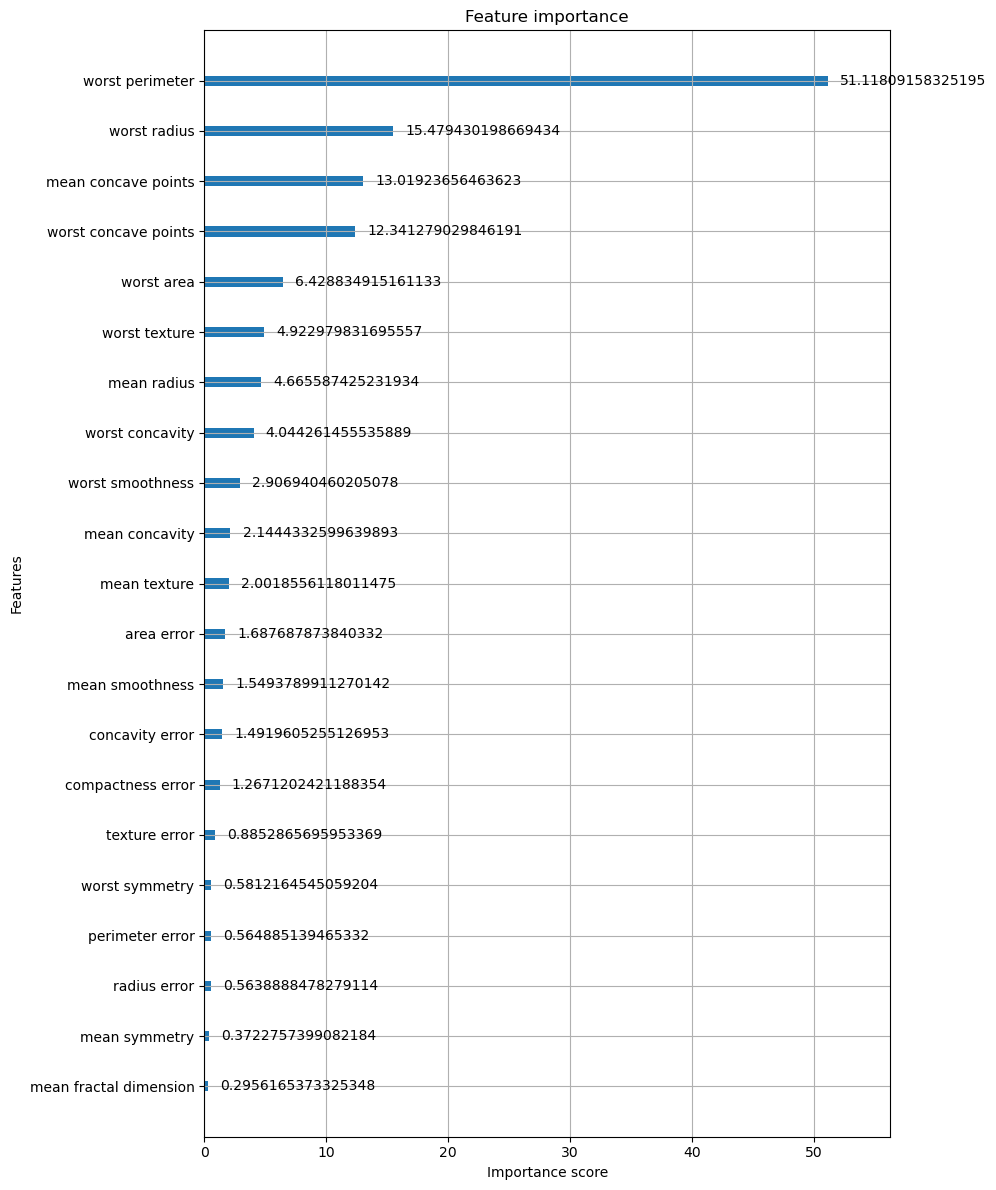

In [94]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(model, ax=ax, importance_type="gain", max_num_features=50)
plt.tight_layout()
plt.show()

## **07 LightGBM**

LightGBM의 가장 큰 장점은 XGBoost보다 학습에 걸리는 시간이 훨씬 적다는 점이다. 또한 메모리 사용량도 상대적으로 적다.

LighGBM의 한 가지 단점으로 알려진 것은 적은 데이터 세트에 적용할 경우 과적합이 발생하기 쉽다는 것이다.

LightGBM은 일반 GBM 계열의 트리 분할 방법과 다르게 리프 중심 트리 분할(Leaf Wise) 방식을 사용한다. 기존의 대부분 트리 기반 알고리즘은 트리의 깊이를 효과적으로 줄이기 위한 균형 트리 분할(Level Wise) 방식을 사용한다. LightGBM의 리프 중심 트리 분할 방식은 트리의 균형을 맞추지 않고, 최대 손실 값(max delta loss)을 가지는 리프 노드를 지속적으로 분할하면서 트리의 깊이가 깊어지고 비대칭적인 규칙 트리가 생성된다.

LightGBM의 XGBoost 대비 장점은 다음과 같이 정리할 수 있다.
- 더 빠른 학습과 예측 수행 시간
- 더 작은 메모리 사용량
- 카테고리형 피처의 자동 변환과 최적 분할(원-핫 인코딩 등을 사용하지 않고도 카테고리형 피처를 최적으로 변환하고 이에 따른 노드 분할 수행)

LightGBM의 대용량 데이터에 대한 뛰어난 예측 성능 및 병렬 컴퓨팅 기능을 제공하고 있으며, 추가로 최근에는 GPU까지 지원하고 있다.

LightGBM의 파이썬 패키지명은 'lightgbm'이다. 사이킷런 래퍼 LightGBM은 추가로 개발되었으며, lightgbm 패키지 내에 이 두 개의 래퍼 모듈을 모두 가지고 있다. 사이킷런 래퍼 LightGBM 클래스는 분류를 위한 LGBMClassifier 클래스와 회귀를 위한 LGBMRegressor 클래스이다.

이 클래스는 사이킷런의 기반 Estimator를 상속 받아 작성됐기 때문에 fit(), predict() 기반의 학습 및 예측과 사이킷런이 제공하는 다양한 유틸리티의 활용이 가능하다.

#### **LightGBM 하이퍼 파라미터**

##### **주요 파라미터**

- **num_iterations [default = 100]**  
  반복 수행하는 트리의 개수를 지정합니다.  
  너무 크게 지정하면 과적합으로 이어질 수 있으며, 너무 작으면 성능이 저하될 수 있습니다.  
  사이킷런 GBM과 XGBoost의 `n_estimators`와 같은 의미이며, LightGBM의 사이킷런 호환 클래스에서는 `n_estimators`로 이름이 변경됩니다.

- **learning_rate [default = 0.1]**  
  0에서 1 사이의 값을 지정하며, 부스팅 스텝을 반복적으로 수행할 때 업데이트되는 학습률을 의미합니다.  
  일반적으로 `n_estimators`를 크게 하고 `learning_rate`를 작게 설정하면 예측 성능이 향상될 수 있으나, 학습 시간이 길어집니다.

- **max_depth [default = -1]**  
  트리 기반 알고리즘의 `max_depth`와 동일합니다.  
  LightGBM은 **Leaf-wise 방식**으로 트리를 성장시키므로 깊이가 자동으로 달라집니다.

- **min_data_in_leaf [default = 20]**  
  결정 트리의 `min_samples_leaf`와 유사합니다.  
  LightGBM 분류기에서는 `min_child_samples`로 이름이 변경됩니다.  
  과적합을 방지하기 위한 중요한 파라미터입니다.

- **num_leaves [default = 31]**  
  하나의 트리가 가질 수 있는 최대 리프 노드의 개수입니다.  
  트리의 복잡도를 조절하는 주요 파라미터입니다.

- **boosting [default = gbdt]**  
  부스팅 트리를 생성하는 알고리즘의 종류입니다.  
  - `gbdt`: 일반적인 Gradient Boosting Decision Tree  
  - `rf`: 랜덤 포레스트 방식

- **bagging_fraction [default = 1.0]**  
  과적합을 방지하기 위해 데이터를 샘플링하는 비율을 의미합니다.

- **feature_fraction [default = 1.0]**  
  각 트리를 생성할 때 사용할 피처의 비율입니다.  
  XGBoost의 `colsample_bytree`와 동일합니다.

- **lambda_l2 [default = 0.0]**  
  L2 정규화를 제어하기 위한 값입니다.  
  XGBoost의 `reg_lambda`와 동일하며, LightGBMClassifier에서는 `reg_lambda`로 변경됩니다.

- **lambda_l1 [default = 0.0]**  
  L1 정규화를 제어하기 위한 값입니다.  
  XGBoost의 `reg_alpha`와 동일하며, LightGBMClassifier에서는 `reg_alpha`로 변경됩니다.


##### **Learning Task 파라미터**

- **objective**  
  최적화할 손실 함수를 정의합니다. XGBoost의 objective 파라미터와 동일합니다. 회귀, 이진, 다중 클래스 분류 등 목적에 따라 손실 함수가 달라집니다.

#### **하이퍼 파라미터 튜닝 방안**

num_leaves의 개수를 중심으로 min_child_samples(min_data_in_leaf), max_depth를 함께 조장하면서 모델의 복잡도를 줄이는 것이 기본 튜닝 방안이다.
- `num_leaves`를 크게 하면 정확도가 높아지지만, 트리의 깊이가 깊어지고 과적합 가능성이 커집니다.  
- `min_data_in_leaf`와 `max_depth`를 함께 고려하여 트리의 깊이를 제한해야 합니다.  
- 과적합을 제어하기 위해 `reg_lambda`, `reg_alpha`, `colsample_bytree`, `subsample` 등의 정규화 및 샘플링 관련 파라미터를 적용할 수 있습니다.


#### **파이썬 래퍼 LightGBM과 사이킷런 래퍼 XGBoost, LightGBM 하이퍼 파라미터 비교**

| 파이썬 래퍼 LightGBM | 사이킷런 래퍼 LightGBM | 사이킷런 래퍼 XGBoost |
|----------------------|------------------------|-----------------------|
| num_iterations | n_estimators | n_estimators |
| learning_rate | learning_rate | learning_rate |
| max_depth | max_depth | max_depth |
| min_data_in_leaf | min_child_samples | N/A |
| bagging_fraction | subsample | subsample |
| feature_fraction | colsample_bytree | colsample_bytree |
| lambda_l2 | reg_lambda | reg_lambda |
| lambda_l1 | reg_alpha | reg_alpha |
| early_stopping_round | early_stopping_rounds | early_stopping_rounds |
| num_leaves | num_leaves | N/A |
| min_sum_hessian_in_leaf | min_child_weight | min_child_weight |


#### **LightGBM 적용 - 위스콘신 유방암 예측**

위스콘신 유방암 데이터 세트를 이용해 LightGBM으로 예측해 본다. LightGBM의 파이썬 패키지인 lightgbm에서 LGBMClassifier을 임포트해 사용한다. LightGBM도 XGBoost와 동일하게 조기 중단(early stopping)이 가능하다.

In [12]:
# LightGBM의 파이썬 패키지인 lightgbm에서 LGBMClassifier 임포트
from lightgbm import LGBMClassifier, early_stopping, log_evaluation

import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# 데이터 로드
dataset = load_breast_cancer()

# DataFrame 생성
cancer_df = pd.DataFrame(data=dataset.data, columns=dataset.feature_names)
cancer_df['target'] = dataset.target

# 피처와 라벨 분리
X_features = cancer_df.iloc[:, :-1]
y_label = cancer_df.iloc[:, -1]

# 전체 데이터 중 80%는 학습용 데이터, 20%는 테스트용 데이터 추출
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_label, test_size=0.2, random_state=156
)

# 학습 데이터 중 10%는 검증용 데이터로 분리
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=156
)

# 모델 생성 (verbosity=-1 추가)
lgbm_wrapper = LGBMClassifier(n_estimators=400, learning_rate=0.05, verbose=1)

# 검증 데이터 지정
evals = [(X_tr, y_tr), (X_val, y_val)]

# 조기 중단 설정 
lgbm_wrapper.fit(
    X_tr, y_tr,
    eval_set=evals,
    eval_metric="logloss",
    callbacks=[early_stopping(stopping_rounds=50)]
)

# 예측 수행
preds = lgbm_wrapper.predict(X_test, num_iteration=lgbm_wrapper.best_iteration_)
pred_proba = lgbm_wrapper.predict_proba(X_test, num_iteration=lgbm_wrapper.best_iteration_)[:, 1]

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 251, number of negative: 158
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000153 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4092
[LightGBM] [Info] Number of data points in the train set: 409, number of used features: 30
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.613692 -> initscore=0.462858
[LightGBM] [Info] Start training from score 0.462858
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

이제 학습된 LightGBM 모델을 기반으로 예측 성능을 평가한다. 앞에서 사용한 get_clf_eval() 함수를 이용한다.

In [14]:
get_clf_eval(y_test, preds, pred_proba)

오차 행렬
[[34  3]
 [ 2 75]]
정확도: 0.9561, 정밀도: 0.9615, 재현율: 0.9740, F1: 0.9677, AUC: 0.9877


LightGBM 파이썬 패키지인 lightgbm은 피처 중요도를 시각화할 수 있는 내장 API를 제공한다. 이름도 동일하게 plot_importance()이다. 또한 사이킷런 래퍼 클래스를 입력해도 시각화를 제공한다.

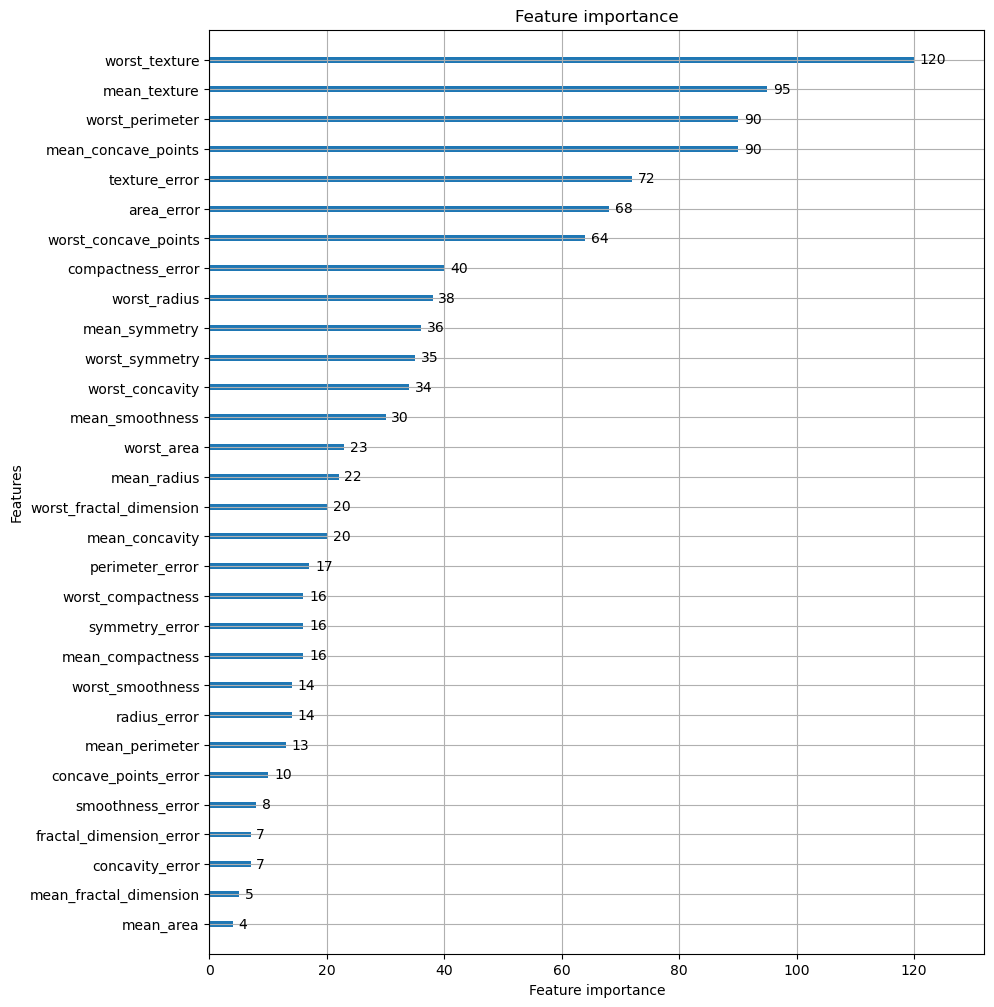

In [17]:
# plot_importance()를 이용하여 feature 중요도 시각화
from lightgbm import plot_importance
import matplotlib.pyplot as plt
%matplotlib inline

fig, ax = plt.subplots(figsize=(10, 12))
plot_importance(lgbm_wrapper, ax=ax)
plt.show()

## **08 베이지안 최적화 기반의 HyperOpt를 이용한 하이퍼 파라미터 튜닝**

지금까지는 하이퍼 파리미터 튜닝을 위해서 사이킷런에서 제공하는 Grid Search 방식을 적용했다. Grid Search 방식은 한 가지 주요한 단점이 있는데, 튜닝해야 할 하이퍼 파라미터 개수가 많을 경우 최적화 수행 시간이 오래 걸린다는 것이다. 

XGBoost나 LightGBM은 성능이 매우 뛰어난 알고리즘이지만, 하이퍼 파라미터 개수가 다른 알고리즘에 비해서 많다. 때문에 실무의 대용량 학습 데이터에 Grid Search 방식으로 최적 하이퍼 파라미터를 찾으려면 많은 시간이 소모될 수 있다.

max_depth는 [10, 20, 30, 40, 50]와 같이 5개의 값을, num_leaves는 4개의 값, colsample_bytree는 5개의 값, subsample은 5개의 값, min_child_weight는 4개의 값, reg_alpha는 3개의 값을 가질 경우 Grid Search 방식 5 x 4 x 5 x 5 x 4 x 3 = 6000회에 걸쳐서 반복적으로 학습과 평가를 수행해야만 하기에 수행 시간이 매우 오래 걸릴 수 밖에 없다.

In [1]:
params = {
'max_depth' : [10, 20, 30, 40, 50], 'num_leaves' : [35, 45, 55, 65],
'colsample_bytree' : [0.5, 0.6, 0.7, 0.8, 0.9], 'subsample' : [0.5, 0.6, 0.7, 0.8, 0.9],
'min_child_weight' : [10, 20, 30, 40], 'reg_alpha' : [0.01, 0.05, 0.1]
}

#### **베이지안 최적화 개요**

베이지안 최적화는 목적 함수 식을 제대로 알 수 없는 블랙 박스 형태의 함수에서 최대 또는 최소 함수 반환 값을 만드는 최적 입력값을 가능한 적은 시도를 통해 빠르고 효과적으로 찾아주는 방식이다.

베이지안 최적화는 이름에서 유추해 볼 수 있듯이 베이지안 확률에 기반을 두고 있는 최적화 기법이다. 베이지안 최적화는 새로운 데이터를 입력받았을 때 최적 함수를 예측하는 사후 모델을 개선해 나가면서 최적 함수 모델을 만들어 낸다.

베이지안 최적화를 구성하는 두 가지 중요 요소는 대체 모델(Surrogate Model)과 획득 함수(Acquisition Function)이다. 대체 모델은 획득 함수로부터 최적 함수를 예측할 수 있는 입력값을 추천 받은 뒤 이를 기반으로 최적 함수 모델을 개선해 나가며, 획득 함수는 개선된 대체 모델을 기반으로 최적 입력값을 계산한다.

베이지안 최적화는 다음과 같은 단계로 구성된다.
- Step 1: 최초에는 랜덤하게 파라미터들을 샘플링하고 성능 결과를 관측한다.
- Step 2: 관측된 값을 기반으로 대체 모델은 최적 함수를 추정한다.
- Step 3: 추정된 최적 함수를 기반으로 획득 함수(Acquisition Function)는 다음으로 관측할 파라미터 값을 계산한다. 획득 함수는 이전의 최적 관측값보다 더 큰 최댓값을 가질 가능성이 높은 지점을 찾아서 다음에 관측할 하이퍼 파라미터를 대체 모델에 전달한다.
- Step 4: 획득 함수로부터 전달된 파라미터를 수행하여 관측된 값을 기반으로 대체 모델은 갱신되어 다시 최적 함수를 예측 추정한다.

이런 방식으로 Step 3와 Step 4를 특정 횟수만큼 반복하게 되면 대체 모델의 불확실성이 개선되고 점차 정확한 최적 함수 추정이 가능하게 된다. 

대체 모델은 최적 함수를 추정할 때 다양한 알고리즘을 사용할 수 있는데 일반적으로는 가우시안 프로세스(Gaussian Process)를 적용한다.

#### **HyperOpt 사용하기**

베이지안 최적화를 머신러닝 모델의 하이퍼 파라미터 튜닝에 적용할 수 있게 제공되는 여러 파이썬 패키지들이 있는데 대표적으로 HyperOpt, Bayesian Optimization, Optuna 등을 들 수 있다. pip를 이용해서 HyperOpt를 설치한다.

In [2]:
pip install hyperopt

   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 28.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


HyperOpt 활용하는 주요 로직은 아래와 같이 구성되어 있다.
- 첫째는 입력 변수명과 입력값의 검색 공간(Search Space) 설정이다.
- 둘째는 목적 함수(Objective Function)의 설정이다.
- 마지막으로 목적 함수의 반환 최솟값을 가지는 최적 입력값을 유추하는 것이다.

HyperOpt를 사용할 유의할 점은 다른 패키지와 다르게 목적 함수 반환 값의 최댓값이 아닌 최솟값을 가지는 최적 입력값을 유추한다는 것이다.

입력 변수명과 입력값 검색 공간은 파이썬 딕셔너리 형태로 설정되어야 하며, 키(key)값으로 입력 변수명, 밸류(value)값으로 해당 입력 변수의 검색 공간이 주어진다. hp 모듈은 입력값의 검색 공간을 다양하게 설정할 수 있도록 여러 가지 함수를 제공한다. hp.quniform('x', -10, 10, 1)과 같이 설정하면 입력 변수는 x는 -10부터 10까까지 1의 가지는 값들, 즉 [-10, -9, -8, ..., 8, 9, 10]와 같은 값들을 가진다(다만 값들은 순차적으로 입력되지 않는다).

In [2]:
from hyperopt import hp

# -10 ~ 10까지 1간격을 가지는 입력 변수 x와 -15와 15까지 1 간격으로 입력 변수 y 설정
search_space = {'x':hp.quniform('x', -10, 10, 1), 'y':hp.quniform('y', -15, 15, 1)}

입력값의 검색 공간을 제공하는 대표적인 함수들은 아래와 같다. 함수 인자로 들어가는 label은 입력 변수명을 다시 적어준다. low는 최솟값, high는 최댓값이며 q는 간격이다.

- hp.quniform(label, low, high, q): label로 지정된 입력값 변수 검색 공간을 최솟값 low에서 최댓값 high까지 q의 간격을 가지고 설정
- hp.uniform(label, low, high): 최솟값 low에서 최댓값 high까지 정규 분포 형태의 검색 공간 설정
- hp.randint(label, upper): 0부터 최댓값 upper까지 random한 정숫값으로 검색 공간 설정
- hp.loguniform(label, low, high): exp(uniform(low, high)값을 반환하며, 반환 값의 log 변환된 값은 정규 분포 형태를 가지는 검색 공간 설정
- hp.choice(label, options): 검색 값이 문자열 또는 문자열과 숫자값이 섞여 있을 경우 설정. options는 리스트나 튜플형태로 제공되며 hp.choice('tree_criterion', ['gini', 'entropy'])과 같이 설정하면 입력 변수 tree_criterion의 값을 'gini'와 'entropy'로 설정하여 입력함

목적 함수는 반드시 변숫값과 검색 공간을 가지는 딕셔너리를 인자로 받고, 트정 값을 반환하는 구조로 만들어져야 한다. 목적 함수의 반환값은 숫자형 단일값 외에도 딕셔너리 형태로 반환할 수 있다. 딕셔너리 형태로 반환할 경우에는 ['loss':retval, 'status':STATUS_OK]와 같이 loss와 status 키 값을 설정해서 반환해야 한다.

In [3]:
from hyperopt import STATUS_OK

# 목적 함수를 생성. 변숫값과 변수 검색 공간을 가지는 딕셔너리를 인자로 받고, 특정 값을 반환
def objective_func(search_space):
    x = search_space['x']
    y = search_space['y']
    retval = x**2 - 20*y

    return retval

HyperOpt는 이러한 기능을 수행할 수 있도록 fmin(objective, space, algo, max_evals, trials) 함수를 제공한다.

fmin() 함수의 주요 인자는 아래와 같다.
- fn: 위에서 생성한 objective_func와 같은 목적 함수이다.
- space: 위에서 생성한 search_space와 같은 검색 공간 딕셔너리이다.
- algo: 베이지안 최적화 적용 알고리즘이다. 기본적으로 tpe.suggest이며 HyperOpt의 기본 최적화 알고리즘인 TPE(Tree of Parzen Estimator)를 의미한다.
- max_evals: 최적 입력값을 찾기 위한 입력값 시도 횟수
- trials: 최적 입력값을 찾기 위해 시도한 입력값 및 해당 입력값의 목적 함수 반환값 결과를 저장하는 데 사용된다. Trials 클래스를 객체로 생성한 변수명을 입력한다.
- rstate: fmin()을 수행할 때마다 동일한 결괏값을 가질 수 있도록 설정하는 랜덤 시드(seed) 값이다.

HyperOpt의 fmin() 함수를 호출하되, 먼저 5번의 입력값 시도로 찾아낼 수 있도록 max_evals 인자 값으로 5를 설정한다. 목적 함수인 fn 인자로는 objective_func를, 검색 공간 인자인 space에는 search_space를, 최적화 적용 알고리즘 algo 인자는 기본값인 tpe.suggest로 설정한다. 또한 trials 인자값으로는 Trials() 객체를, 그리고 rstate의 경우는 임의의 랜덤 시드값을 입력한다.

In [4]:
from hyperopt import fmin, tpe, Trials
import numpy as np
# 입력 결괏값을 저장한 Trials 객체값 생성
trial_val = Trials()

# 목적 함수의 최솟값을 반환하는 최적 입력 변숫값을 5번의 입력값 시도(max_evals=5)로 찾아냄
best_01 = fmin(fn=objective_func, space=search_space, algo=tpe.suggest, max_evals=5,
               trials=trial_val, rstate=np.random.default_rng(seed=0))
print('best:', best_01)

100%|████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 2498.39trial/s, best loss: -224.0]
best: {'x': -4.0, 'y': 12.0}


max_evals 값을 20으로 설정하여 20번의 수행으로 어떤 최적값을 반환하는지 살펴본다.

In [6]:
trial_val = Trials()

# max_evals를 20회로 늘려서 재테스트
best_02 = fmin(fn=objective_func, space=search_space, algo=tpe.suggest, max_evals=20,
               trials=trial_val, rstate=np.random.default_rng(seed=0))
print('best:', best_02)

100%|██████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 2153.91trial/s, best loss: -296.0]
best: {'x': 2.0, 'y': 15.0}


완벽한 정답인 x=0은 도출하지 못했지만, 입력값 x가 -10 ~ 10까지 21개의 경우의 수, 입력값 y가 -15 ~ 15까지 31개의 경우의 수를 가질 수 있기에, 만일 그리드 서치와 같이 순차적으로 x, y 변숫값을 입력해서 최소 함수 반환값을 찾는다면 최대 21 * 31 = 651 회의 반복이 필요할 수도 있는데 반해서, 베이지안 최적화를 이용해서는 20회의 반복만으로 일정 수준의 최적값을 근사해 낼 수 있었다.

Trials 객체의 중요 속성은 results와 vals가 있다. 이 중 result는 함수의 반복 수행 시마다 반환되는 반환값을 가진다. 그리고 vals는 함수의 반복 수행 시마다 입력되는 입력 변숫값을 가진다. 이들 중 먼저 results 속성을 알아본다. results는 파이썬 리스트 형태이며 리스트 내의 개별 원소는 {'loss':함수 반환값, 'status':반환 상태값}과 같은 딕셔너리로 가지고 있다.

In [7]:
# fmin()에 인자로 들어가는 Trials 객체의 result 속성에 파이썬 리스트로 목적 함수 반환값들이 저장됨
# 리스트 내부의 개별 원소는 {'loss':함수 반환값, 'status':반환 상태값}와 같은 딕셔너리임
print(trial_val.results)

[{'loss': -64.0, 'status': 'ok'}, {'loss': -184.0, 'status': 'ok'}, {'loss': 56.0, 'status': 'ok'}, {'loss': -224.0, 'status': 'ok'}, {'loss': 61.0, 'status': 'ok'}, {'loss': -296.0, 'status': 'ok'}, {'loss': -40.0, 'status': 'ok'}, {'loss': 281.0, 'status': 'ok'}, {'loss': 64.0, 'status': 'ok'}, {'loss': 100.0, 'status': 'ok'}, {'loss': 60.0, 'status': 'ok'}, {'loss': -39.0, 'status': 'ok'}, {'loss': 1.0, 'status': 'ok'}, {'loss': -164.0, 'status': 'ok'}, {'loss': 21.0, 'status': 'ok'}, {'loss': -56.0, 'status': 'ok'}, {'loss': 284.0, 'status': 'ok'}, {'loss': 176.0, 'status': 'ok'}, {'loss': -171.0, 'status': 'ok'}, {'loss': 0.0, 'status': 'ok'}]


max_evals=20으로 fmin() 함수는 20회의 반복 수행을 했으므로 results 속성은 loss와 status를 키 값으로 가지는 20개의 딕셔너리를 개별 원소를 가지는 리스트로 구성되어 있음을 알 수 있다. Trials 객체의 vals 속성은 딕셔너리 형태로 값을 가진다. fmin() 함수 수행 시마다 입력되는 입력 변수값들을 {'입력변수명': 개별 수행 시마다 입력된 값 리스트}와 같은 형태로 가지고 있다.

In [10]:
# Trials 객체의 vals 속성에 {'입력변수명': 개별 수행 시마다 입력된 값 리스트} 형태로 저장됨
print(trial_val.vals)

{'x': [-6.0, -4.0, 4.0, -4.0, 9.0, 2.0, 10.0, -9.0, -8.0, -0.0, -0.0, 1.0, 9.0, 6.0, 9.0, 2.0, -2.0, -4.0, 7.0, -0.0], 'y': [5.0, 10.0, -2.0, 12.0, 1.0, 15.0, 7.0, -10.0, 0.0, -5.0, -3.0, 2.0, 4.0, 10.0, 3.0, 3.0, -14.0, -8.0, 11.0, -0.0]}


Trials 객체의 results와 vals 속성은 HyperOpt의 fmin() 함수의 수행 시마다 최적화되는 경과를 볼 수 있는 함수 반환값과 입력 변숫값들의 정보를 제공해 준다. results와 vals 속성값들을 DataFrame으로 만들어서 좀 더 직관적으로 값을 확인해 본다.

In [11]:
import pandas as pd

# results에서 loss 키값에 해당하는 밸류들을 추출하여 list로 생성
losses = [loss_dict['loss'] for loss_dict in trial_val.results]

# DataFrame으로 생성
result_df = pd.DataFrame({'x':trial_val.vals['x'], 'y':trial_val.vals['y'], 'losses':losses})
result_df

,x,y,losses
0,-6.0,5.0,-64.0
1,-4.0,10.0,-184.0
2,4.0,-2.0,56.0
3,-4.0,12.0,-224.0
4,9.0,1.0,61.0
5,2.0,15.0,-296.0
6,10.0,7.0,-40.0
7,-9.0,-10.0,281.0
8,-8.0,0.0,64.0
9,-0.0,-5.0,100.0


#### **HyperOpt를 이용한 XGBoost 하이퍼 파라미터 최적화**